# 继续加深网络：7 → 16 → 32 → 1，与 Lasso 比较

参考 `01_MLP的构建.ipynb` 第 12 节，使用两层隐藏层，第一层 16 个、第二层 32 个神经元，各层后接 ReLU，输出层保持线性，共 **705 个可训练参数**。七个输入因子与目标口径不变。

沿用刚才指定的日期划分：**截至 2025-12-31 为内部拟合集，2026 年 1—3 月为内部验证集，2026-04-01 起为测试集**。

Adam、学习率 0.01、seed=42、最多 2000 轮；验证标准化 MSE 下降超过 1e-6 才记为改善，连续 100 轮未改善则早停。重新为两层网络选择训练轮数，不沿用旧小网络的 291 轮。选轮后重新初始化，在截至 2026-03-31 的完整训练集上重训选定轮数。

Lasso 使用相同完整训练／测试样本，仍采用标准化 Pipeline、五折时间序列交叉验证、10⁻⁵～10¹ 的 1000 个 alpha。两种模型的外部划分相同，内部调参规则不同。

保留 MSE、指标表和预测对比，另用独立单元格展示 **2024-01-01 至 2026-03-31** 的训练期放大图及局部 RMSE、R²；不新增残差图。本节可从头独立运行。

In [ ]:
from pathlib import Path
from copy import deepcopy
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / 'src/pickle/Dataset.pkl').exists())
OUT = PROJECT_ROOT / 'results/mlp_two_layer_2026q1'
OUT.mkdir(parents=True, exist_ok=True)
SEED, LR = 42, 0.01
HIDDEN_LAYERS = (16, 32)
MAX_EPOCHS, PATIENCE, MIN_DELTA = 2000, 100, 1e-6
VAL_START = pd.Timestamp('2026-01-01')
TEST_START = pd.Timestamp('2026-04-01')
torch.set_num_threads(1)
device = torch.device('cpu')
print('PyTorch:', torch.__version__)


PyTorch: 2.14.0


## 1. 新的日期划分和范围覆盖

扩大训练范围之后，仍需检查黄金、铜和利率是否超出完整训练期范围。范围内不等于所有组合都已见过，范围外也不等于预测必然失败。

In [ ]:
dataset_path = PROJECT_ROOT / 'src/pickle/Dataset.pkl'
Dataset = pd.read_pickle(dataset_path)
X = Dataset['X'].copy()
Y = Dataset['Y'].copy()
expected = ['A_500', 'Dollar Index', 'cn_10y_rate', 'us_10y_rate',
            'brent', 'Copper Futures Price', 'Gold Futures Price']
assert list(X.columns) == expected and X.index.equals(Y.index)
assert isinstance(X.index, pd.DatetimeIndex)
assert X.index.is_monotonic_increasing and X.index.is_unique
assert np.isfinite(X.to_numpy()).all() and np.isfinite(Y.to_numpy()).all()
X_train, X_test = X.loc[X.index < TEST_START].copy(), X.loc[X.index >= TEST_START].copy()
Y_train, Y_test = Y.loc[X_train.index].copy(), Y.loc[X_test.index].copy()
X_fit = X_train.loc[X_train.index < VAL_START].copy()
X_val = X_train.loc[X_train.index >= VAL_START].copy()
Y_fit, Y_val = Y_train.loc[X_fit.index], Y_train.loc[X_val.index]
assert X_fit.index.max() < VAL_START <= X_val.index.min()
assert X_val.index.max() < TEST_START
assert X_fit.index.append(X_val.index).equals(X_train.index)
assert min(len(X_fit), len(X_val), len(X_test)) > 1
assert X_fit.index.max() < X_val.index.min() <= X_val.index.max() < X_test.index.min()
split_info = pd.DataFrame([
    {'数据段': name, '记录数': len(frame), '开始': frame.index.min(), '结束': frame.index.max()}
    for name, frame in [('完整训练集', X_train), ('内部拟合集', X_fit),
                        ('内部验证集', X_val), ('测试集', X_test)]])
display(split_info)


,数据段,记录数,开始,结束
0,完整训练集,3754,2012-05-09,2026-03-31
1,内部拟合集,3685,2012-05-09,2025-12-31
2,内部验证集,69,2026-01-01,2026-03-31
3,测试集,83,2026-04-01,2026-07-23


In [ ]:
coverage = pd.DataFrame(index=X.columns)
for label, reference, future in [
    ('验证超出内部拟合范围 (%)', X_fit, X_val),
    ('测试超出内部拟合范围 (%)', X_fit, X_test),
    ('测试超出完整训练范围 (%)', X_train, X_test)]:
    coverage[label] = ((future < reference.min()) | (future > reference.max())).mean() * 100
display(coverage.round(2))


,验证超出内部拟合范围 (%),测试超出内部拟合范围 (%),测试超出完整训练范围 (%)
A_500,0.00,0.00,0.00
Dollar Index,0.00,0.00,0.00
cn_10y_rate,0.00,0.00,0.00
us_10y_rate,0.00,0.00,0.00
brent,0.00,3.61,3.61
Copper Futures Price,50.72,91.57,59.04
Gold Futures Price,81.16,45.78,0.00


## 2. MLP：标准化、训练及验证早停

标准化器仅在内部拟合集拟合。下图记录每轮更新后的内部拟合／验证 MSE，纵轴为标准化目标的平方单位。

In [ ]:
scaler_x = StandardScaler().fit(X_fit)
scaler_y = StandardScaler().fit(Y_fit.to_numpy().reshape(-1, 1))
def to_tensor(values):
    return torch.tensor(np.asarray(values), dtype=torch.float32, device=device)
X_fit_tensor = to_tensor(scaler_x.transform(X_fit))
X_val_tensor = to_tensor(scaler_x.transform(X_val))
Y_fit_tensor = to_tensor(scaler_y.transform(Y_fit.to_numpy().reshape(-1, 1)))
Y_val_tensor = to_tensor(scaler_y.transform(Y_val.to_numpy().reshape(-1, 1)))
def build_mlp():
    torch.manual_seed(SEED)
    return nn.Sequential(
        nn.Linear(7, HIDDEN_LAYERS[0]), nn.ReLU(),
        nn.Linear(HIDDEN_LAYERS[0], HIDDEN_LAYERS[1]), nn.ReLU(),
        nn.Linear(HIDDEN_LAYERS[1], 1)
    ).to(device)
model = build_mlp()
loss_fn = nn.MSELoss()
print(model)
print('参数数量：', sum(p.numel() for p in model.parameters()))


Sequential(
  (0): Linear(in_features=7, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)
参数数量： 705


最佳轮数：76；实际停止轮数：176；停止原因：连续 100 轮未明显改善
最佳验证标准化 MSE：0.027193


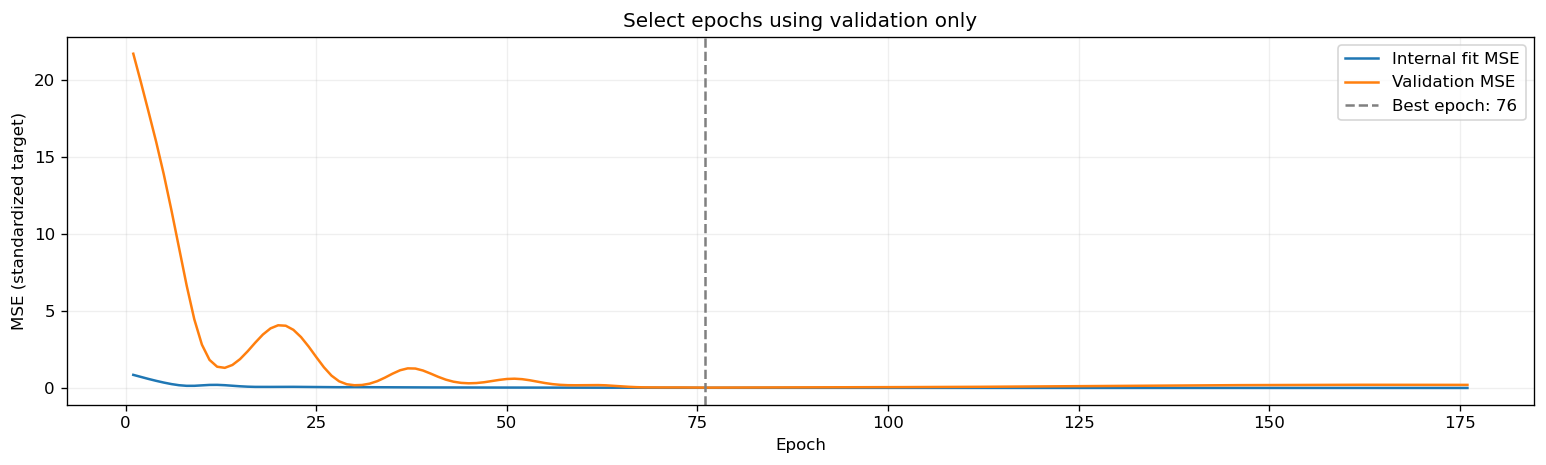

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
best_val_loss, best_epoch, waiting = float('inf'), 0, 0
best_state = None
history_rows = []
for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    loss = loss_fn(model(X_fit_tensor), Y_fit_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.eval()
    with torch.no_grad():
        fit_mse = loss_fn(model(X_fit_tensor), Y_fit_tensor).item()
        val_mse = loss_fn(model(X_val_tensor), Y_val_tensor).item()
    assert np.isfinite(fit_mse) and np.isfinite(val_mse)
    history_rows.append([epoch, fit_mse, val_mse])
    if val_mse < best_val_loss - MIN_DELTA:
        best_val_loss, best_epoch, waiting = val_mse, epoch, 0
        best_state = deepcopy(model.state_dict())
    else:
        waiting += 1
    if waiting >= PATIENCE:
        break
last_epoch = epoch
model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    assert np.isclose(loss_fn(model(X_val_tensor), Y_val_tensor).item(), best_val_loss)
history = pd.DataFrame(history_rows, columns=['epoch', 'fit_mse', 'val_mse'])
history.to_csv(OUT / 'selection_history.csv', index=False)
print(f'最佳轮数：{best_epoch}；实际停止轮数：{last_epoch}；'
      f'停止原因：{"连续 100 轮未明显改善" if waiting >= PATIENCE else "达到轮数上限"}')
print(f'最佳验证标准化 MSE：{best_val_loss:.6f}')
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(history.epoch, history.fit_mse, label='Internal fit MSE')
ax.plot(history.epoch, history.val_mse, label='Validation MSE')
ax.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch: {best_epoch}')
ax.set(xlabel='Epoch', ylabel='MSE (standardized target)', title='Select epochs using validation only')
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'selection_mse.png', dpi=140)
plt.show()


## 3. MLP：完整训练期重训

使用验证选定轮数，在截至 2026-03-31 的全部训练样本上重新训练。标准化器也只在这段完整训练数据上重新拟合。保存内部最佳权重和最终模型，以及配套的标准化参数。

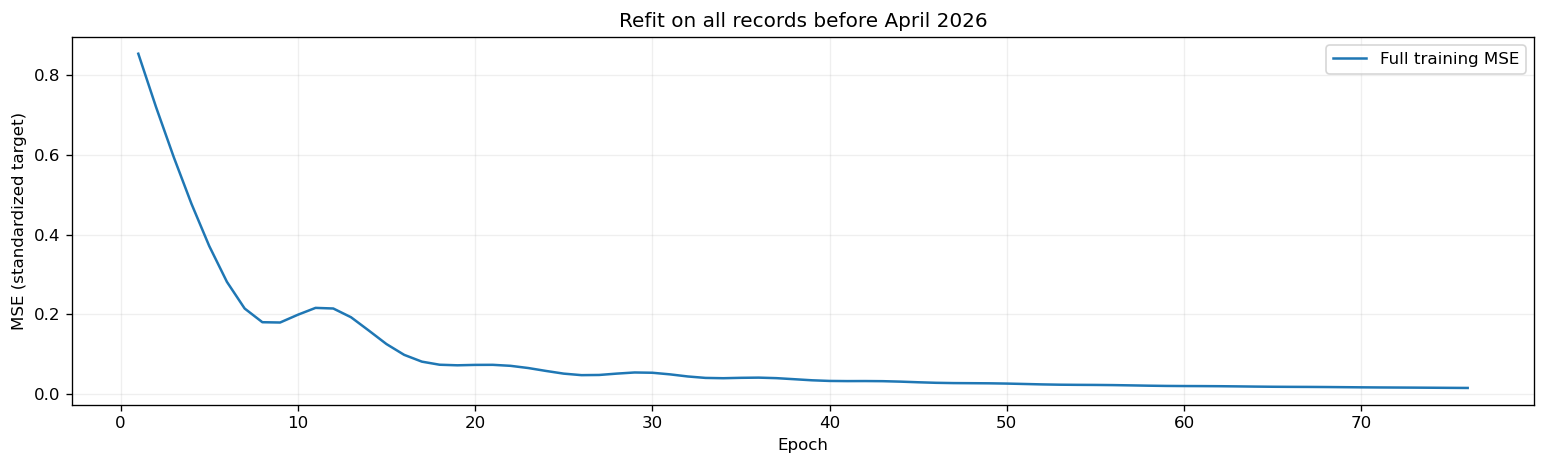

In [ ]:
scaler_x_final = StandardScaler().fit(X_train)
scaler_y_final = StandardScaler().fit(Y_train.to_numpy().reshape(-1, 1))
X_train_tensor = to_tensor(scaler_x_final.transform(X_train))
Y_train_tensor = to_tensor(scaler_y_final.transform(Y_train.to_numpy().reshape(-1, 1)))
mlp = build_mlp()
final_optimizer = torch.optim.Adam(mlp.parameters(), lr=LR)
final_losses = []
for epoch in range(1, best_epoch + 1):
    mlp.train()
    loss = loss_fn(mlp(X_train_tensor), Y_train_tensor)
    final_optimizer.zero_grad()
    loss.backward()
    final_optimizer.step()
    mlp.eval()
    with torch.no_grad():
        final_losses.append(loss_fn(mlp(X_train_tensor), Y_train_tensor).item())
assert np.isfinite(final_losses).all()
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(range(1, best_epoch + 1), final_losses, label='Full training MSE')
ax.set(xlabel='Epoch', ylabel='MSE (standardized target)', title='Refit on all records before April 2026')
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'refit_mse.png', dpi=140)
plt.show()

# 同时保存两阶段权重及各自的标准化参数；恢复时必须配套使用。
def scaler_state(scaler):
    return {'mean': scaler.mean_.tolist(), 'scale': scaler.scale_.tolist()}
torch.save({
    'model_state_dict': mlp.state_dict(), 'internal_best_state_dict': best_state,
    'feature_names': list(X.columns), 'hidden_layers': list(HIDDEN_LAYERS), 'seed': SEED, 'lr': LR,
    'best_epoch': best_epoch, 'stopped_epoch': last_epoch,
    'max_epochs': MAX_EPOCHS, 'patience': PATIENCE, 'min_delta': MIN_DELTA,
    'test_start': str(TEST_START.date()), 'validation_start': str(VAL_START.date()), 'validation_end_exclusive': str(TEST_START.date()),
    'scaler_x_final': scaler_state(scaler_x_final), 'scaler_y_final': scaler_state(scaler_y_final),
    'scaler_x_internal': scaler_state(scaler_x), 'scaler_y_internal': scaler_state(scaler_y),
    'dataset_sha256': hashlib.sha256(dataset_path.read_bytes()).hexdigest()
}, OUT / 'mlp_checkpoint.pt')


## 4. 最终 MLP 预测

保持前面预测图的数据格式，计算原股价单位下的误差，不保存残差列。

In [ ]:
def predict_price(frame):
    mlp.eval()
    with torch.no_grad():
        values = mlp(to_tensor(scaler_x_final.transform(frame))).cpu().numpy()
    return scaler_y_final.inverse_transform(values).ravel()
predictions = {}
metric_rows = []
for label, features, truth in [('Train', X_train, Y_train), ('Test', X_test, Y_test)]:
    pred = predict_price(features)
    actual = np.asarray(truth).ravel()
    residual = actual - pred
    frame = pd.DataFrame({'Actual': actual, 'Predicted': pred}, index=truth.index)
    assert np.isfinite(frame.to_numpy()).all()
    predictions[label] = frame
    frame.to_csv(OUT / f'{label.lower()}_predictions.csv')
    mse = mean_squared_error(actual, pred)
    metric_rows.append({'数据段': label, 'MSE': mse, 'RMSE': np.sqrt(mse),
                       'MAE': np.abs(residual).mean(), 'R²': r2_score(actual, pred)})
metrics = pd.DataFrame(metric_rows).set_index('数据段')
metrics.to_csv(OUT / 'metrics.csv')
display(metrics.round(4))


,MSE,RMSE,MAE,R²
数据段,,,,
Train,0.7731,0.8793,0.5404,0.9849
Test,64.3132,8.0196,7.5204,-6.5592


## 5. Lasso：相同训练集，时间序列交叉验证

每折单独拟合 StandardScaler，alpha 范围仍为 10⁻⁵～10¹，共 1000 个候选，按平均验证 RMSE 选择。最终在完整训练集自动重新拟合。

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import joblib

lasso_2026q1_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])
lasso_2026q1_search = GridSearchCV(
    lasso_2026q1_pipeline,
    param_grid={'lasso__alpha': np.logspace(-5, 1, 1000)},
    cv=TimeSeriesSplit(n_splits=5), scoring='neg_root_mean_squared_error',
    refit=True, return_train_score=True, n_jobs=1, error_score='raise')
lasso_2026q1_search.fit(X_train, np.asarray(Y_train).ravel())
print('Lasso 最佳 alpha：', lasso_2026q1_search.best_params_['lasso__alpha'])
print('五折平均验证 RMSE：', -lasso_2026q1_search.best_score_)
print('最终模型迭代次数：', lasso_2026q1_search.best_estimator_['lasso'].n_iter_)
joblib.dump(lasso_2026q1_search.best_estimator_, OUT / 'lasso_pipeline.joblib')


Lasso 最佳 alpha： 0.011092898648952227
五折平均验证 RMSE： 2.1767398276435452
最终模型迭代次数： 57


## 6. Lasso 的拟合／验证 MSE

横轴是 alpha，不是训练轮数。两条曲线是五折各自拟合段、验证段 MSE 的算术平均值，使用原股价平方单位；竖线按平均验证 RMSE 选择，不一定对应平均 MSE 的最低点。Lasso 使用坐标下降求解，不具有与 MLP 相同的 epoch 学习曲线。

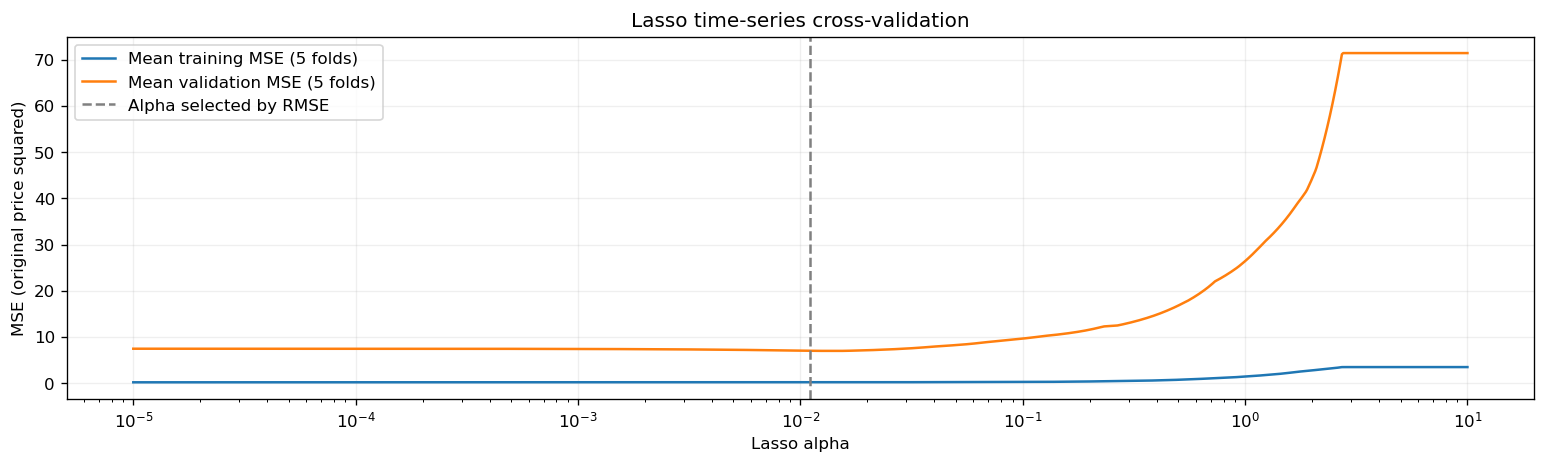

In [ ]:
lasso_cv = pd.DataFrame(lasso_2026q1_search.cv_results_)
lasso_cv_alpha = lasso_cv['param_lasso__alpha'].astype(float).to_numpy()
lasso_fold_rmse = np.column_stack([
    -lasso_cv[f'split{k}_test_score'].to_numpy() for k in range(5)])
lasso_fold_train_rmse = np.column_stack([
    -lasso_cv[f'split{k}_train_score'].to_numpy() for k in range(5)])
lasso_cv_summary = pd.DataFrame({
    'alpha': lasso_cv_alpha,
    'mean_training_mse': (lasso_fold_train_rmse ** 2).mean(axis=1),
    'mean_validation_rmse': lasso_fold_rmse.mean(axis=1),
    'mean_validation_mse': (lasso_fold_rmse ** 2).mean(axis=1)})
lasso_cv_summary.to_csv(OUT / 'lasso_cv.csv', index=False)
fig, ax = plt.subplots(figsize=(13, 4))
ax.semilogx(lasso_cv_alpha, lasso_cv_summary.mean_training_mse, label='Mean training MSE (5 folds)')
ax.semilogx(lasso_cv_alpha, lasso_cv_summary.mean_validation_mse, label='Mean validation MSE (5 folds)')
ax.axvline(lasso_2026q1_search.best_params_['lasso__alpha'], color='gray', linestyle='--', label='Alpha selected by RMSE')
ax.set(xlabel='Lasso alpha', ylabel='MSE (original price squared)', title='Lasso time-series cross-validation')
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'lasso_cv_mse.png', dpi=140)
plt.show()


## 7. MLP 与 Lasso：同一时间范围的指标表

最终模型都使用完整训练集，测试集均从 2026-04-01 开始。MSE、RMSE、MAE 越小越好，R² 越大越好。

In [ ]:
comparison_predictions = {}
comparison_rows = []
for split, features, truth in [('Train', X_train, Y_train), ('Test', X_test, Y_test)]:
    assert predictions[split].index.equals(truth.index)
    assert np.allclose(predictions[split]['Actual'], np.asarray(truth).ravel())
    frame = predictions[split][['Actual', 'Predicted']].rename(columns={'Predicted': 'MLP'}).copy()
    frame['Lasso'] = lasso_2026q1_search.predict(features)
    assert np.isfinite(frame.to_numpy()).all()
    comparison_predictions[split] = frame
    frame.to_csv(OUT / f'comparison_{split.lower()}_predictions.csv')
    for name in ['MLP', 'Lasso']:
        residual = frame.Actual - frame[name]
        mse = mean_squared_error(frame.Actual, frame[name])
        comparison_rows.append({'数据段': split, '模型': name, 'MSE': mse,
            'RMSE': np.sqrt(mse), 'MAE': np.abs(residual).mean(),
            'R²': r2_score(frame.Actual, frame[name])})
comparison_metrics = pd.DataFrame(comparison_rows).set_index(['数据段', '模型'])
display(comparison_metrics.round(4))
comparison_metrics.to_csv(OUT / 'comparison_metrics.csv')
print('测试集 RMSE 较小的模型：', comparison_metrics.loc['Test', 'RMSE'].idxmin())
print('MLP 相对 Lasso 的测试 RMSE 降幅：'
      f"{(1 - comparison_metrics.loc[('Test', 'MLP'), 'RMSE'] / comparison_metrics.loc[('Test', 'Lasso'), 'RMSE']) * 100:.2f}%（负值表示 MLP 更差）")


测试集 RMSE 较小的模型： Lasso
MLP 相对 Lasso 的测试 RMSE 降幅：-239.85%（负值表示 MLP 更差）


MSE    RMSE     MAE      R²
数据段   模型                                    
Train MLP     0.7731  0.8793  0.5404  0.9849
      Lasso   1.6796  1.2960  0.9357  0.9672
Test  MLP    64.3132  8.0196  7.5204 -6.5592
      Lasso   5.5683  2.3597  1.8478  0.3455

## 8. 训练集／测试集预测对比

蓝线为实际股价，橙线为 MLP，绿线为 Lasso。灰色区间曾用于 MLP 选轮，在最终重训时已参与两个模型的训练；淡紫色区域为最终测试期。

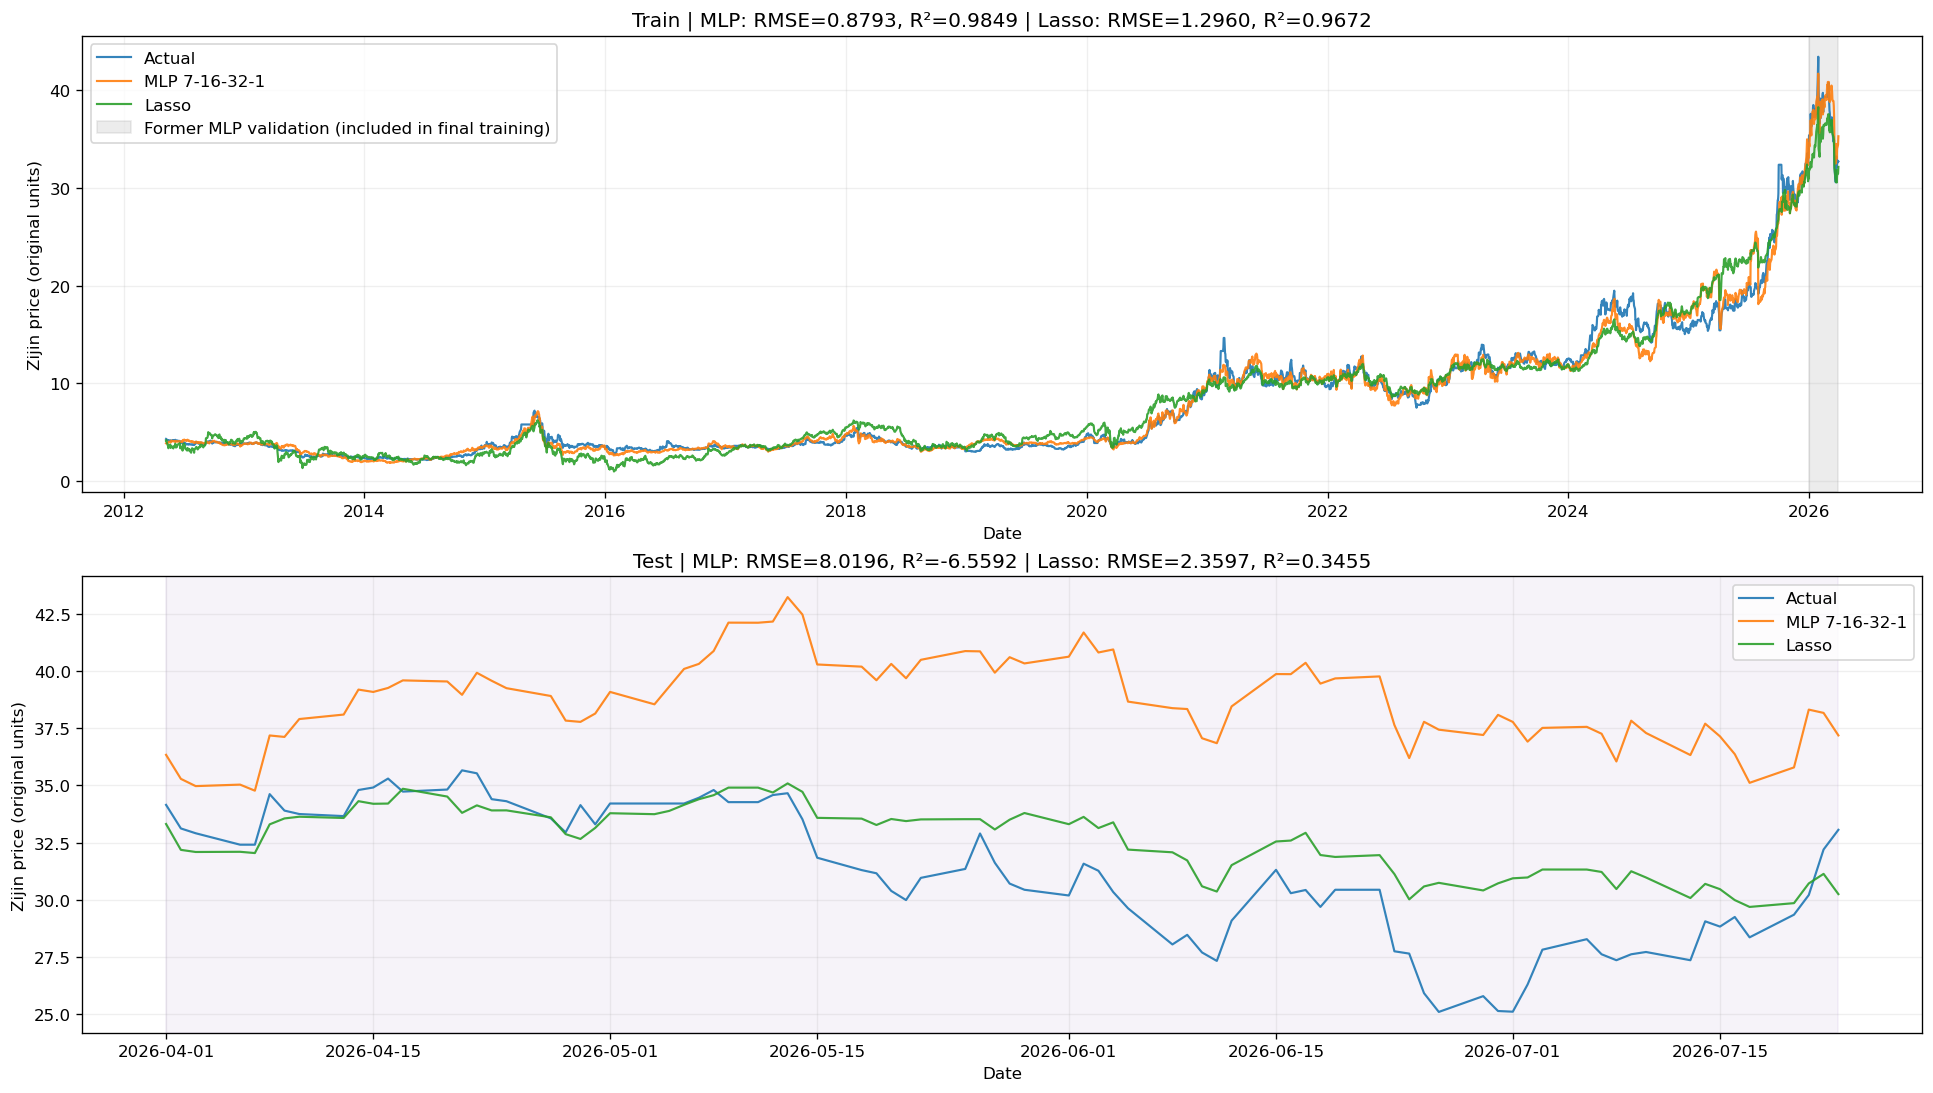

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)
for ax, split in zip(axes, ['Train', 'Test']):
    frame = comparison_predictions[split]
    for name, color in [('Actual', 'tab:blue'), ('MLP', 'tab:orange'), ('Lasso', 'tab:green')]:
        ax.plot(frame.index, frame[name], color=color, label='MLP 7-16-32-1' if name == 'MLP' else name, linewidth=1.3, alpha=0.9)
    if split == 'Train':
        ax.axvspan(X_val.index.min(), X_val.index.max(), color='gray', alpha=0.15,
                   label='Former MLP validation (included in final training)')
    else:
        ax.axvspan(frame.index.min(), frame.index.max(), color='tab:purple', alpha=0.08)
    row_mlp = comparison_metrics.loc[(split, 'MLP')]
    row_lasso = comparison_metrics.loc[(split, 'Lasso')]
    ax.set(title=f'{split} | MLP: RMSE={row_mlp.RMSE:.4f}, R²={row_mlp["R²"]:.4f}'
           f' | Lasso: RMSE={row_lasso.RMSE:.4f}, R²={row_lasso["R²"]:.4f}',
           xlabel='Date', ylabel='Zijin price (original units)')
    ax.grid(alpha=0.2)
    ax.legend()
fig.savefig(OUT / 'mlp_lasso_predictions.png', dpi=140)
plt.show()


## 9. 单独查看 2024 年至 2026 年 3 月的训练拟合

只截取本次两层网络与 Lasso 的最终训练预测，不重新训练。RMSE 与 R² 在截取后的样本上重新计算，R² 的参照均值也属于这段样本。灰色一季度已参与最终重训，因此这里不是样本外测试结果。

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import display

zoom_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'src/pickle/Dataset.pkl').exists())
zoom_out = zoom_root / 'results/mlp_two_layer_2026q1'
zoom_full = pd.read_csv(zoom_out / 'comparison_train_predictions.csv', index_col=0, parse_dates=True)
zoom_train = zoom_full.loc['2024-01-01':'2026-03-31', ['Actual', 'MLP', 'Lasso']].copy()
assert len(zoom_train) > 1 and np.isfinite(zoom_train.to_numpy()).all()
assert zoom_train.index.max() < pd.Timestamp('2026-04-01')
zoom_metrics = pd.DataFrame([
    {'模型': name, '样本数': len(zoom_train),
     'RMSE': np.sqrt(mean_squared_error(zoom_train.Actual, zoom_train[name])),
     'R²': r2_score(zoom_train.Actual, zoom_train[name])}
    for name in ['MLP', 'Lasso']]).set_index('模型')
print(f'局部训练期：{zoom_train.index.min().date()} 至 {zoom_train.index.max().date()}')
display(zoom_metrics.round(4))
zoom_metrics.to_csv(zoom_out / 'train_2024_to_2026q1_metrics.csv')
zoom_train.to_csv(zoom_out / 'train_2024_to_2026q1_predictions.csv')


局部训练期：2024-01-01 至 2026-03-31


,样本数,RMSE,R²
模型,,,
MLP,610,1.8994,0.9388
Lasso,610,2.5328,0.8911


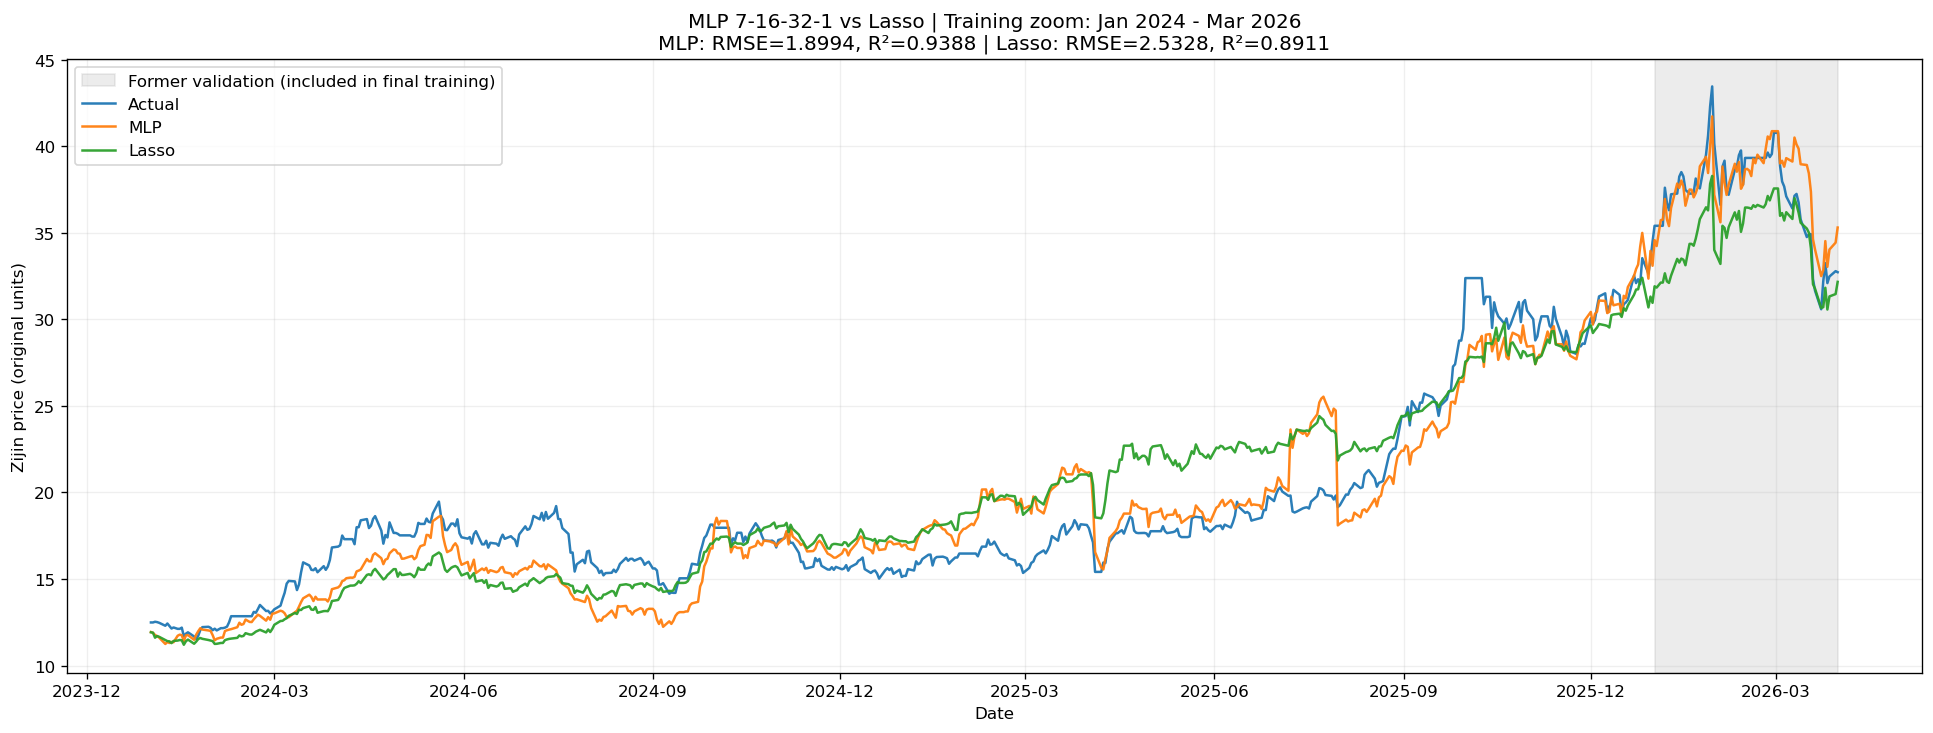

In [ ]:
import matplotlib.dates as mdates

zoom_fig, zoom_ax = plt.subplots(figsize=(16, 6), constrained_layout=True)
zoom_ax.axvspan(pd.Timestamp('2026-01-01'), pd.Timestamp('2026-03-31'),
               color='gray', alpha=0.15, label='Former validation (included in final training)')
for name, color in [('Actual', 'tab:blue'), ('MLP', 'tab:orange'), ('Lasso', 'tab:green')]:
    zoom_ax.plot(zoom_train.index, zoom_train[name], color=color, linewidth=1.5,
                 label=name, alpha=0.95)
zoom_ax.set_title('MLP 7-16-32-1 vs Lasso | Training zoom: Jan 2024 - Mar 2026\n'
    f'MLP: RMSE={zoom_metrics.loc["MLP", "RMSE"]:.4f}, R²={zoom_metrics.loc["MLP", "R²"]:.4f}'
    f' | Lasso: RMSE={zoom_metrics.loc["Lasso", "RMSE"]:.4f}, R²={zoom_metrics.loc["Lasso", "R²"]:.4f}')
zoom_ax.set(xlabel='Date', ylabel='Zijin price (original units)')
zoom_ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
zoom_ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
zoom_ax.grid(alpha=0.2)
zoom_ax.legend(loc='upper left')
zoom_fig.savefig(zoom_out / 'train_2024_to_2026q1_zoom.png', dpi=140)
plt.show()


## 本次运行记录

| 数据段     |   记录数 | 开始                | 结束                |
|:-----------|---------:|:--------------------|:--------------------|
| 完整训练集 |     3754 | 2012-05-09 00:00:00 | 2026-03-31 00:00:00 |
| 内部拟合集 |     3685 | 2012-05-09 00:00:00 | 2025-12-31 00:00:00 |
| 内部验证集 |       69 | 2026-01-01 00:00:00 | 2026-03-31 00:00:00 |
| 测试集     |       83 | 2026-04-01 00:00:00 | 2026-07-23 00:00:00 |

两层 MLP 最佳轮数 **76**，实际停止轮数 **176**；在完整训练集重训 76 轮。Lasso 最佳 alpha **0.011092899**。

完整训练／测试指标：

|                    |     MSE |   RMSE |    MAE |      R² |
|:-------------------|--------:|-------:|-------:|--------:|
| ('Train', 'MLP')   |  0.7731 | 0.8793 | 0.5404 |  0.9849 |
| ('Train', 'Lasso') |  1.6796 | 1.296  | 0.9357 |  0.9672 |
| ('Test', 'MLP')    | 64.3132 | 8.0196 | 7.5204 | -6.5592 |
| ('Test', 'Lasso')  |  5.5683 | 2.3597 | 1.8478 |  0.3455 |

2024 年至 2026 年 3 月局部训练拟合：

| 模型   |   样本数 |   RMSE |     R² |
|:-------|---------:|-------:|-------:|
| MLP    |      610 | 1.8994 | 0.9388 |
| Lasso  |      610 | 2.5328 | 0.8911 |

模型权重、标准化参数、预测明细与图片保存在 `results/mlp_two_layer_2026q1/`。本次为固定种子的一次探索实验，未检查初始化稳定性；这些测试日期已在前面实验中查看过。沿用原始数据与同日解释口径，不代表明日预测。修改数据、参数后需同步更新本段。

---

## 总结:  
继续加深跟原来的简单网络并没有太大差别,我们应该放弃加深,更多考虑的是数据集取值范围的变化和额外信息的引入.加入了非线性的因素以后,2025年9月后的上升趋势与模型预测相近.  
而其中,2025年7月左右的暴涨暴跌,难以解释,需要进一步探究.

In [ ]:
coverage = pd.DataFrame(index=X.columns)
for label, reference, future in [
    ('验证超出内部拟合范围 (%)', X_fit, X_val),
    ('测试超出内部拟合范围 (%)', X_fit, X_test),
    ('测试超出完整训练范围 (%)', X_train, X_test)]:
    coverage[label] = ((future < reference.min()) | (future > reference.max())).mean() * 100
display(coverage.round(2))


,验证超出内部拟合范围 (%),测试超出内部拟合范围 (%),测试超出完整训练范围 (%)
A_500,0.00,0.00,0.00
Dollar Index,0.00,0.00,0.00
cn_10y_rate,0.00,0.00,0.00
us_10y_rate,0.00,0.00,0.00
brent,0.00,3.61,3.61
Copper Futures Price,50.72,91.57,59.04
Gold Futures Price,81.16,45.78,0.00


这一段说明,虽然我们通过改变拟合,验证,测试集的范围,让美元与美债,原油的价格影响减小,模型训练有了相关经验.  
对于黄金和铜价,由于通货膨胀影响,价格整体呈现上升趋势,而近年来涨幅明显.我们测试2022年以前的数据,此时价格相对稳定,且数据集大部分没有位置的情况.

In [ ]:
coverage = pd.DataFrame(index=X.columns)
for label, reference, future in [
    ('验证超出内部拟合范围 (%)', X_fit, X_val),
    ('测试超出内部拟合范围 (%)', X_fit, X_test),
    ('测试超出完整训练范围 (%)', X_train, X_test)]:
    coverage[label] = ((future < reference.min()) | (future > reference.max())).mean() * 100
display(coverage.round(2))


,验证超出内部拟合范围 (%),测试超出内部拟合范围 (%),测试超出完整训练范围 (%)
A_500,0.00,0.00,0.00
Dollar Index,0.00,0.00,0.00
cn_10y_rate,0.00,0.00,0.00
us_10y_rate,0.00,0.00,0.00
brent,0.00,3.61,3.61
Copper Futures Price,50.72,91.57,59.04
Gold Futures Price,81.16,45.78,0.00


## 假设历史数据相对稳定,那么模型的预测效果如何?

# 历史区间实验：2021—2022 年测试，之前训练

检验较早时期是否输入范围覆盖更充分、模型泛化更好，不预设 2021—2022 年一定稳定。

**训练集：2021-01-01 之前；测试集：2021-01-01 至 2022-12-31（包含两个完整年份）**。训练集末尾 5% 作为内部验证集。2023 年及以后记录不参与本实验的训练、选参、评价。

保持两层 MLP 7→16→32→1、seed=42、Adam、LR=0.01、最多 2000 轮、MIN_DELTA=1e-6、连续 100 轮验证无改善早停。选轮后重新初始化，在完整训练集重训。Lasso 保持五折 TimeSeriesSplit 和原 alpha 网格，两者使用完全相同的外部划分。

保留覆盖表、MSE 曲线、指标表和预测对比，不新增残差。范围覆盖只是单变量检查，不能证明变量联合关系稳定；不同测试期的分数不可直接用来确定误差原因。

In [ ]:
from pathlib import Path
from copy import deepcopy
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / 'src/pickle/Dataset.pkl').exists())
OUT = PROJECT_ROOT / 'results/mlp_two_layer_test_2021_2022'
OUT.mkdir(parents=True, exist_ok=True)
SEED, LR = 42, 0.01
HIDDEN_LAYERS = (16, 32)
MAX_EPOCHS, PATIENCE, MIN_DELTA = 2000, 100, 1e-6
TEST_START = pd.Timestamp('2021-01-01')
TEST_END = pd.Timestamp('2023-01-01')  # 右端点不包含
VAL_FRACTION = 0.05
torch.set_num_threads(1)
device = torch.device('cpu')
print('PyTorch:', torch.__version__)


PyTorch: 2.14.0


## 1. 新的日期划分和范围覆盖

扩大训练范围之后，仍需检查黄金、铜和利率是否超出完整训练期范围。范围内不等于所有组合都已见过，范围外也不等于预测必然失败。

In [ ]:
dataset_path = PROJECT_ROOT / 'src/pickle/Dataset.pkl'
Dataset = pd.read_pickle(dataset_path)
X = Dataset['X'].copy()
Y = Dataset['Y'].copy()
X = X.loc[X.index < TEST_END].copy()
Y = Y.loc[X.index].copy()
expected = ['A_500', 'Dollar Index', 'cn_10y_rate', 'us_10y_rate',
            'brent', 'Copper Futures Price', 'Gold Futures Price']
assert list(X.columns) == expected and X.index.equals(Y.index)
assert isinstance(X.index, pd.DatetimeIndex)
assert X.index.is_monotonic_increasing and X.index.is_unique
assert np.isfinite(X.to_numpy()).all() and np.isfinite(Y.to_numpy()).all()
X_train, X_test = X.loc[X.index < TEST_START].copy(), X.loc[X.index >= TEST_START].copy()
Y_train, Y_test = Y.loc[X_train.index].copy(), Y.loc[X_test.index].copy()
cut = int(len(X_train) * (1 - VAL_FRACTION))
X_fit, X_val = X_train.iloc[:cut].copy(), X_train.iloc[cut:].copy()
Y_fit, Y_val = Y_train.loc[X_fit.index], Y_train.loc[X_val.index]
VAL_START = X_val.index.min()
assert X_test.index.max() < TEST_END
assert X_fit.index.max() < VAL_START <= X_val.index.min()
assert X_val.index.max() < TEST_START
assert X_fit.index.append(X_val.index).equals(X_train.index)
assert min(len(X_fit), len(X_val), len(X_test)) > 1
assert X_fit.index.max() < X_val.index.min() <= X_val.index.max() < X_test.index.min()
split_info = pd.DataFrame([
    {'数据段': name, '记录数': len(frame), '开始': frame.index.min(), '结束': frame.index.max()}
    for name, frame in [('完整训练集', X_train), ('内部拟合集', X_fit),
                        ('内部验证集', X_val), ('测试集', X_test)]])
display(split_info)


,数据段,记录数,开始,结束
0,完整训练集,2325,2012-05-09,2020-12-31
1,内部拟合集,2208,2012-05-09,2020-07-24
2,内部验证集,117,2020-07-27,2020-12-31
3,测试集,546,2021-01-01,2022-12-31


In [ ]:
coverage = pd.DataFrame(index=X.columns)
for label, reference, future in [
    ('验证超出内部拟合范围 (%)', X_fit, X_val),
    ('测试超出内部拟合范围 (%)', X_fit, X_test),
    ('测试超出完整训练范围 (%)', X_train, X_test)]:
    coverage[label] = ((future < reference.min()) | (future > reference.max())).mean() * 100
display(coverage.round(2))

coverage.to_csv(OUT / 'coverage.csv')


,验证超出内部拟合范围 (%),测试超出内部拟合范围 (%),测试超出完整训练范围 (%)
A_500,0.00,3.11,3.11
Dollar Index,0.00,30.40,30.40
cn_10y_rate,0.00,0.00,0.00
us_10y_rate,0.85,17.95,17.95
brent,0.00,6.23,6.23
Copper Futures Price,0.00,69.23,69.23
Gold Futures Price,55.56,11.36,0.00


## 2. MLP：标准化、训练及验证早停

标准化器仅在内部拟合集拟合。下图记录每轮更新后的内部拟合／验证 MSE，纵轴为标准化目标的平方单位。

In [ ]:
scaler_x = StandardScaler().fit(X_fit)
scaler_y = StandardScaler().fit(Y_fit.to_numpy().reshape(-1, 1))
def to_tensor(values):
    return torch.tensor(np.asarray(values), dtype=torch.float32, device=device)
X_fit_tensor = to_tensor(scaler_x.transform(X_fit))
X_val_tensor = to_tensor(scaler_x.transform(X_val))
Y_fit_tensor = to_tensor(scaler_y.transform(Y_fit.to_numpy().reshape(-1, 1)))
Y_val_tensor = to_tensor(scaler_y.transform(Y_val.to_numpy().reshape(-1, 1)))
def build_mlp():
    torch.manual_seed(SEED)
    return nn.Sequential(
        nn.Linear(7, HIDDEN_LAYERS[0]), nn.ReLU(),
        nn.Linear(HIDDEN_LAYERS[0], HIDDEN_LAYERS[1]), nn.ReLU(),
        nn.Linear(HIDDEN_LAYERS[1], 1)
    ).to(device)
model = build_mlp()
loss_fn = nn.MSELoss()
print(model)
print('参数数量：', sum(p.numel() for p in model.parameters()))


Sequential(
  (0): Linear(in_features=7, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)
参数数量： 705


最佳轮数：287；实际停止轮数：387；停止原因：连续 100 轮未明显改善
最佳验证标准化 MSE：1.586699


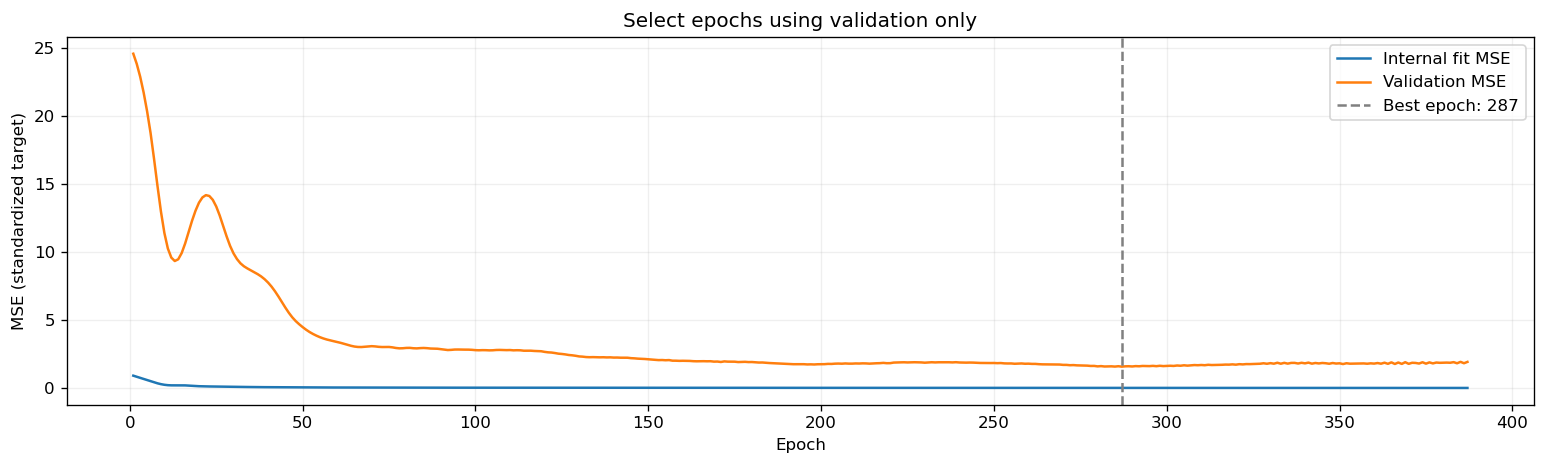

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
best_val_loss, best_epoch, waiting = float('inf'), 0, 0
best_state = None
history_rows = []
for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    loss = loss_fn(model(X_fit_tensor), Y_fit_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.eval()
    with torch.no_grad():
        fit_mse = loss_fn(model(X_fit_tensor), Y_fit_tensor).item()
        val_mse = loss_fn(model(X_val_tensor), Y_val_tensor).item()
    assert np.isfinite(fit_mse) and np.isfinite(val_mse)
    history_rows.append([epoch, fit_mse, val_mse])
    if val_mse < best_val_loss - MIN_DELTA:
        best_val_loss, best_epoch, waiting = val_mse, epoch, 0
        best_state = deepcopy(model.state_dict())
    else:
        waiting += 1
    if waiting >= PATIENCE:
        break
last_epoch = epoch
model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    assert np.isclose(loss_fn(model(X_val_tensor), Y_val_tensor).item(), best_val_loss)
history = pd.DataFrame(history_rows, columns=['epoch', 'fit_mse', 'val_mse'])
history.to_csv(OUT / 'selection_history.csv', index=False)
print(f'最佳轮数：{best_epoch}；实际停止轮数：{last_epoch}；'
      f'停止原因：{"连续 100 轮未明显改善" if waiting >= PATIENCE else "达到轮数上限"}')
print(f'最佳验证标准化 MSE：{best_val_loss:.6f}')
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(history.epoch, history.fit_mse, label='Internal fit MSE')
ax.plot(history.epoch, history.val_mse, label='Validation MSE')
ax.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch: {best_epoch}')
ax.set(xlabel='Epoch', ylabel='MSE (standardized target)', title='Select epochs using validation only')
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'selection_mse.png', dpi=140)
plt.show()


## 3. MLP：完整训练期重训

使用验证选定轮数，在截至 2020-12-31 的全部训练样本上重新训练。标准化器也只在这段完整训练数据上重新拟合。保存内部最佳权重和最终模型，以及配套的标准化参数。

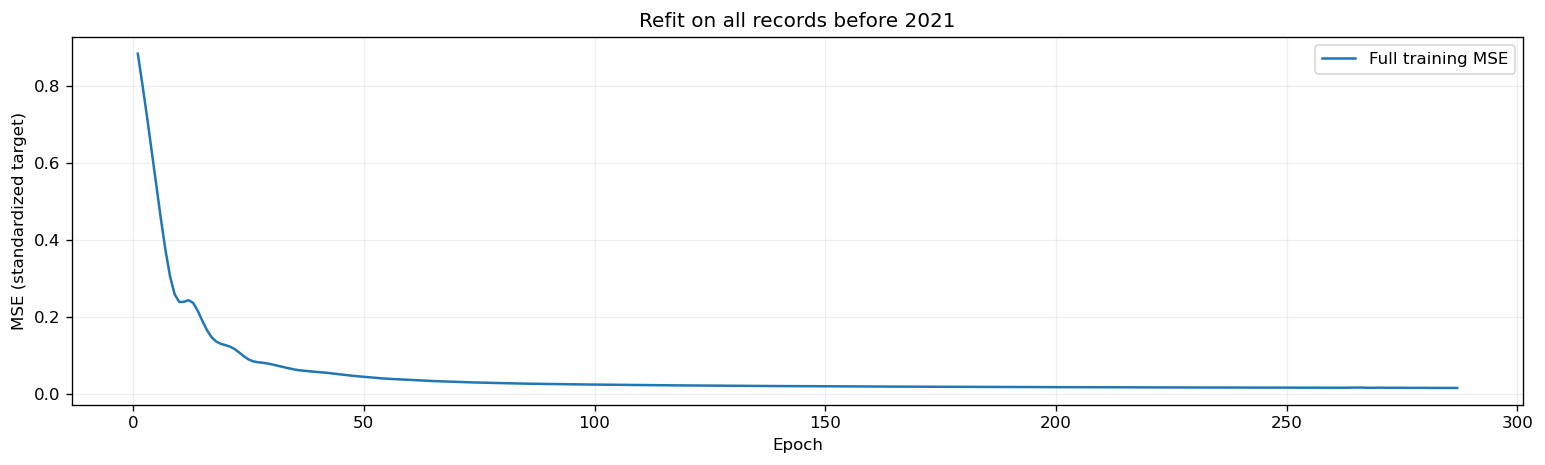

In [ ]:
scaler_x_final = StandardScaler().fit(X_train)
scaler_y_final = StandardScaler().fit(Y_train.to_numpy().reshape(-1, 1))
X_train_tensor = to_tensor(scaler_x_final.transform(X_train))
Y_train_tensor = to_tensor(scaler_y_final.transform(Y_train.to_numpy().reshape(-1, 1)))
mlp = build_mlp()
final_optimizer = torch.optim.Adam(mlp.parameters(), lr=LR)
final_losses = []
for epoch in range(1, best_epoch + 1):
    mlp.train()
    loss = loss_fn(mlp(X_train_tensor), Y_train_tensor)
    final_optimizer.zero_grad()
    loss.backward()
    final_optimizer.step()
    mlp.eval()
    with torch.no_grad():
        final_losses.append(loss_fn(mlp(X_train_tensor), Y_train_tensor).item())
assert np.isfinite(final_losses).all()
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(range(1, best_epoch + 1), final_losses, label='Full training MSE')
ax.set(xlabel='Epoch', ylabel='MSE (standardized target)', title='Refit on all records before 2021')
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'refit_mse.png', dpi=140)
plt.show()

# 同时保存两阶段权重及各自的标准化参数；恢复时必须配套使用。
def scaler_state(scaler):
    return {'mean': scaler.mean_.tolist(), 'scale': scaler.scale_.tolist()}
torch.save({
    'model_state_dict': mlp.state_dict(), 'internal_best_state_dict': best_state,
    'feature_names': list(X.columns), 'hidden_layers': list(HIDDEN_LAYERS), 'seed': SEED, 'lr': LR,
    'best_epoch': best_epoch, 'stopped_epoch': last_epoch,
    'max_epochs': MAX_EPOCHS, 'patience': PATIENCE, 'min_delta': MIN_DELTA,
    'test_start': str(TEST_START.date()), 'test_end_exclusive': str(TEST_END.date()), 'validation_fraction': VAL_FRACTION, 'validation_start': str(VAL_START.date()), 'validation_end_exclusive': str(TEST_START.date()),
    'scaler_x_final': scaler_state(scaler_x_final), 'scaler_y_final': scaler_state(scaler_y_final),
    'scaler_x_internal': scaler_state(scaler_x), 'scaler_y_internal': scaler_state(scaler_y),
    'dataset_sha256': hashlib.sha256(dataset_path.read_bytes()).hexdigest()
}, OUT / 'mlp_checkpoint.pt')


## 4. 最终 MLP 预测

保持前面预测图的数据格式，计算原股价单位下的误差，不保存残差列。

In [ ]:
def predict_price(frame):
    mlp.eval()
    with torch.no_grad():
        values = mlp(to_tensor(scaler_x_final.transform(frame))).cpu().numpy()
    return scaler_y_final.inverse_transform(values).ravel()
predictions = {}
metric_rows = []
for label, features, truth in [('Train', X_train, Y_train), ('Test', X_test, Y_test)]:
    pred = predict_price(features)
    actual = np.asarray(truth).ravel()
    residual = actual - pred
    frame = pd.DataFrame({'Actual': actual, 'Predicted': pred}, index=truth.index)
    assert np.isfinite(frame.to_numpy()).all()
    predictions[label] = frame
    frame.to_csv(OUT / f'{label.lower()}_predictions.csv')
    mse = mean_squared_error(actual, pred)
    metric_rows.append({'数据段': label, 'MSE': mse, 'RMSE': np.sqrt(mse),
                       'MAE': np.abs(residual).mean(), 'R²': r2_score(actual, pred)})
metrics = pd.DataFrame(metric_rows).set_index('数据段')
metrics.to_csv(OUT / 'metrics.csv')
display(metrics.round(4))


,MSE,RMSE,MAE,R²
数据段,,,,
Train,0.0191,0.1380,0.0970,0.9851
Test,4.9503,2.2249,1.7273,-2.9824


## 5. Lasso：相同训练集，时间序列交叉验证

每折单独拟合 StandardScaler，alpha 范围仍为 10⁻⁵～10¹，共 1000 个候选，按平均验证 RMSE 选择。最终在完整训练集自动重新拟合。

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import joblib

lasso_historical_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])
lasso_historical_search = GridSearchCV(
    lasso_historical_pipeline,
    param_grid={'lasso__alpha': np.logspace(-5, 1, 1000)},
    cv=TimeSeriesSplit(n_splits=5), scoring='neg_root_mean_squared_error',
    refit=True, return_train_score=True, n_jobs=1, error_score='raise')
lasso_historical_search.fit(X_train, np.asarray(Y_train).ravel())
print('Lasso 最佳 alpha：', lasso_historical_search.best_params_['lasso__alpha'])
print('五折平均验证 RMSE：', -lasso_historical_search.best_score_)
print('最终模型迭代次数：', lasso_historical_search.best_estimator_['lasso'].n_iter_)
joblib.dump(lasso_historical_search.best_estimator_, OUT / 'lasso_pipeline.joblib')


Lasso 最佳 alpha： 0.008768856094587427
五折平均验证 RMSE： 0.5504101163785309
最终模型迭代次数： 63


## 6. Lasso 的拟合／验证 MSE

横轴是 alpha，不是训练轮数。两条曲线是五折各自拟合段、验证段 MSE 的算术平均值，使用原股价平方单位；竖线按平均验证 RMSE 选择，不一定对应平均 MSE 的最低点。Lasso 使用坐标下降求解，不具有与 MLP 相同的 epoch 学习曲线。

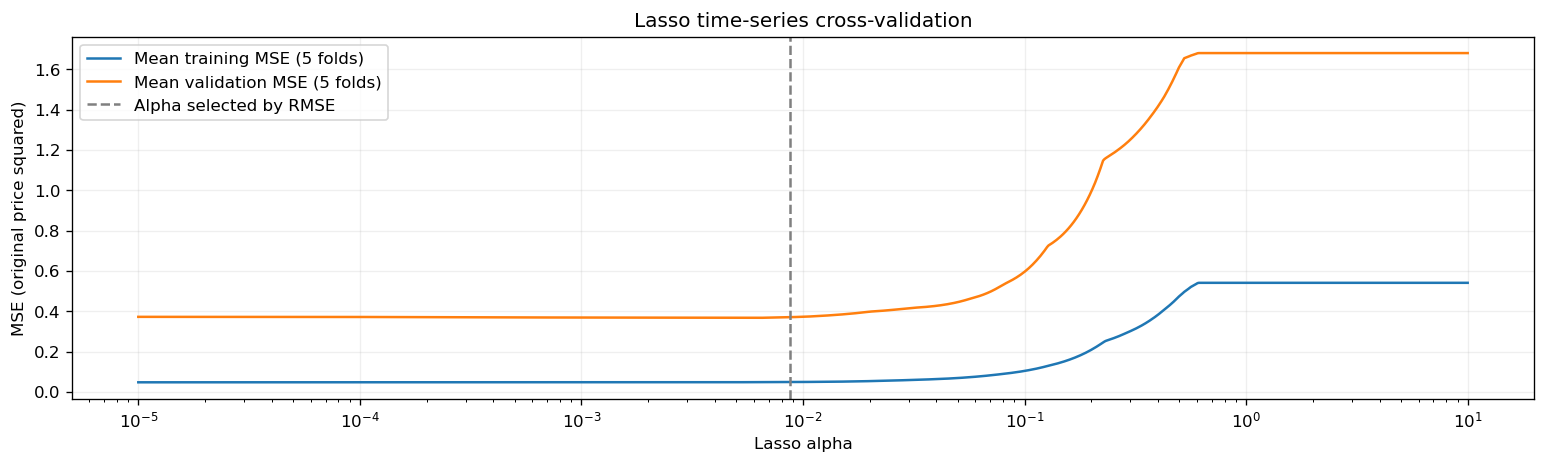

In [ ]:
lasso_cv = pd.DataFrame(lasso_historical_search.cv_results_)
lasso_cv_alpha = lasso_cv['param_lasso__alpha'].astype(float).to_numpy()
lasso_fold_rmse = np.column_stack([
    -lasso_cv[f'split{k}_test_score'].to_numpy() for k in range(5)])
lasso_fold_train_rmse = np.column_stack([
    -lasso_cv[f'split{k}_train_score'].to_numpy() for k in range(5)])
lasso_cv_summary = pd.DataFrame({
    'alpha': lasso_cv_alpha,
    'mean_training_mse': (lasso_fold_train_rmse ** 2).mean(axis=1),
    'mean_validation_rmse': lasso_fold_rmse.mean(axis=1),
    'mean_validation_mse': (lasso_fold_rmse ** 2).mean(axis=1)})
lasso_cv_summary.to_csv(OUT / 'lasso_cv.csv', index=False)
fig, ax = plt.subplots(figsize=(13, 4))
ax.semilogx(lasso_cv_alpha, lasso_cv_summary.mean_training_mse, label='Mean training MSE (5 folds)')
ax.semilogx(lasso_cv_alpha, lasso_cv_summary.mean_validation_mse, label='Mean validation MSE (5 folds)')
ax.axvline(lasso_historical_search.best_params_['lasso__alpha'], color='gray', linestyle='--', label='Alpha selected by RMSE')
ax.set(xlabel='Lasso alpha', ylabel='MSE (original price squared)', title='Lasso time-series cross-validation')
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'lasso_cv_mse.png', dpi=140)
plt.show()


## 7. MLP 与 Lasso：同一时间范围的指标表

最终模型都使用完整训练集，测试集均为 2021—2022 年。MSE、RMSE、MAE 越小越好，R² 越大越好。

In [ ]:
comparison_predictions = {}
comparison_rows = []
for split, features, truth in [('Train', X_train, Y_train), ('Test', X_test, Y_test)]:
    assert predictions[split].index.equals(truth.index)
    assert np.allclose(predictions[split]['Actual'], np.asarray(truth).ravel())
    frame = predictions[split][['Actual', 'Predicted']].rename(columns={'Predicted': 'MLP'}).copy()
    frame['Lasso'] = lasso_historical_search.predict(features)
    assert np.isfinite(frame.to_numpy()).all()
    comparison_predictions[split] = frame
    frame.to_csv(OUT / f'comparison_{split.lower()}_predictions.csv')
    for name in ['MLP', 'Lasso']:
        residual = frame.Actual - frame[name]
        mse = mean_squared_error(frame.Actual, frame[name])
        comparison_rows.append({'数据段': split, '模型': name, 'MSE': mse,
            'RMSE': np.sqrt(mse), 'MAE': np.abs(residual).mean(),
            'R²': r2_score(frame.Actual, frame[name])})
comparison_metrics = pd.DataFrame(comparison_rows).set_index(['数据段', '模型'])
display(comparison_metrics.round(4))
comparison_metrics.to_csv(OUT / 'comparison_metrics.csv')
print('测试集 RMSE 较小的模型：', comparison_metrics.loc['Test', 'RMSE'].idxmin())
print('MLP 相对 Lasso 的测试 RMSE 降幅：'
      f"{(1 - comparison_metrics.loc[('Test', 'MLP'), 'RMSE'] / comparison_metrics.loc[('Test', 'Lasso'), 'RMSE']) * 100:.2f}%（负值表示 MLP 更差）")


测试集 RMSE 较小的模型： MLP
MLP 相对 Lasso 的测试 RMSE 降幅：32.35%（负值表示 MLP 更差）


MSE    RMSE     MAE      R²
数据段   模型                                    
Train MLP     0.0191  0.1380  0.0970  0.9851
      Lasso   0.1831  0.4279  0.3231  0.8569
Test  MLP     4.9503  2.2249  1.7273 -2.9824
      Lasso  10.8166  3.2889  3.1270 -7.7017

## 8. 训练集／测试集预测对比

蓝线为实际股价，橙线为 MLP，绿线为 Lasso。灰色区间曾用于 MLP 选轮，在最终重训时已参与两个模型的训练；淡紫色区域为最终测试期。

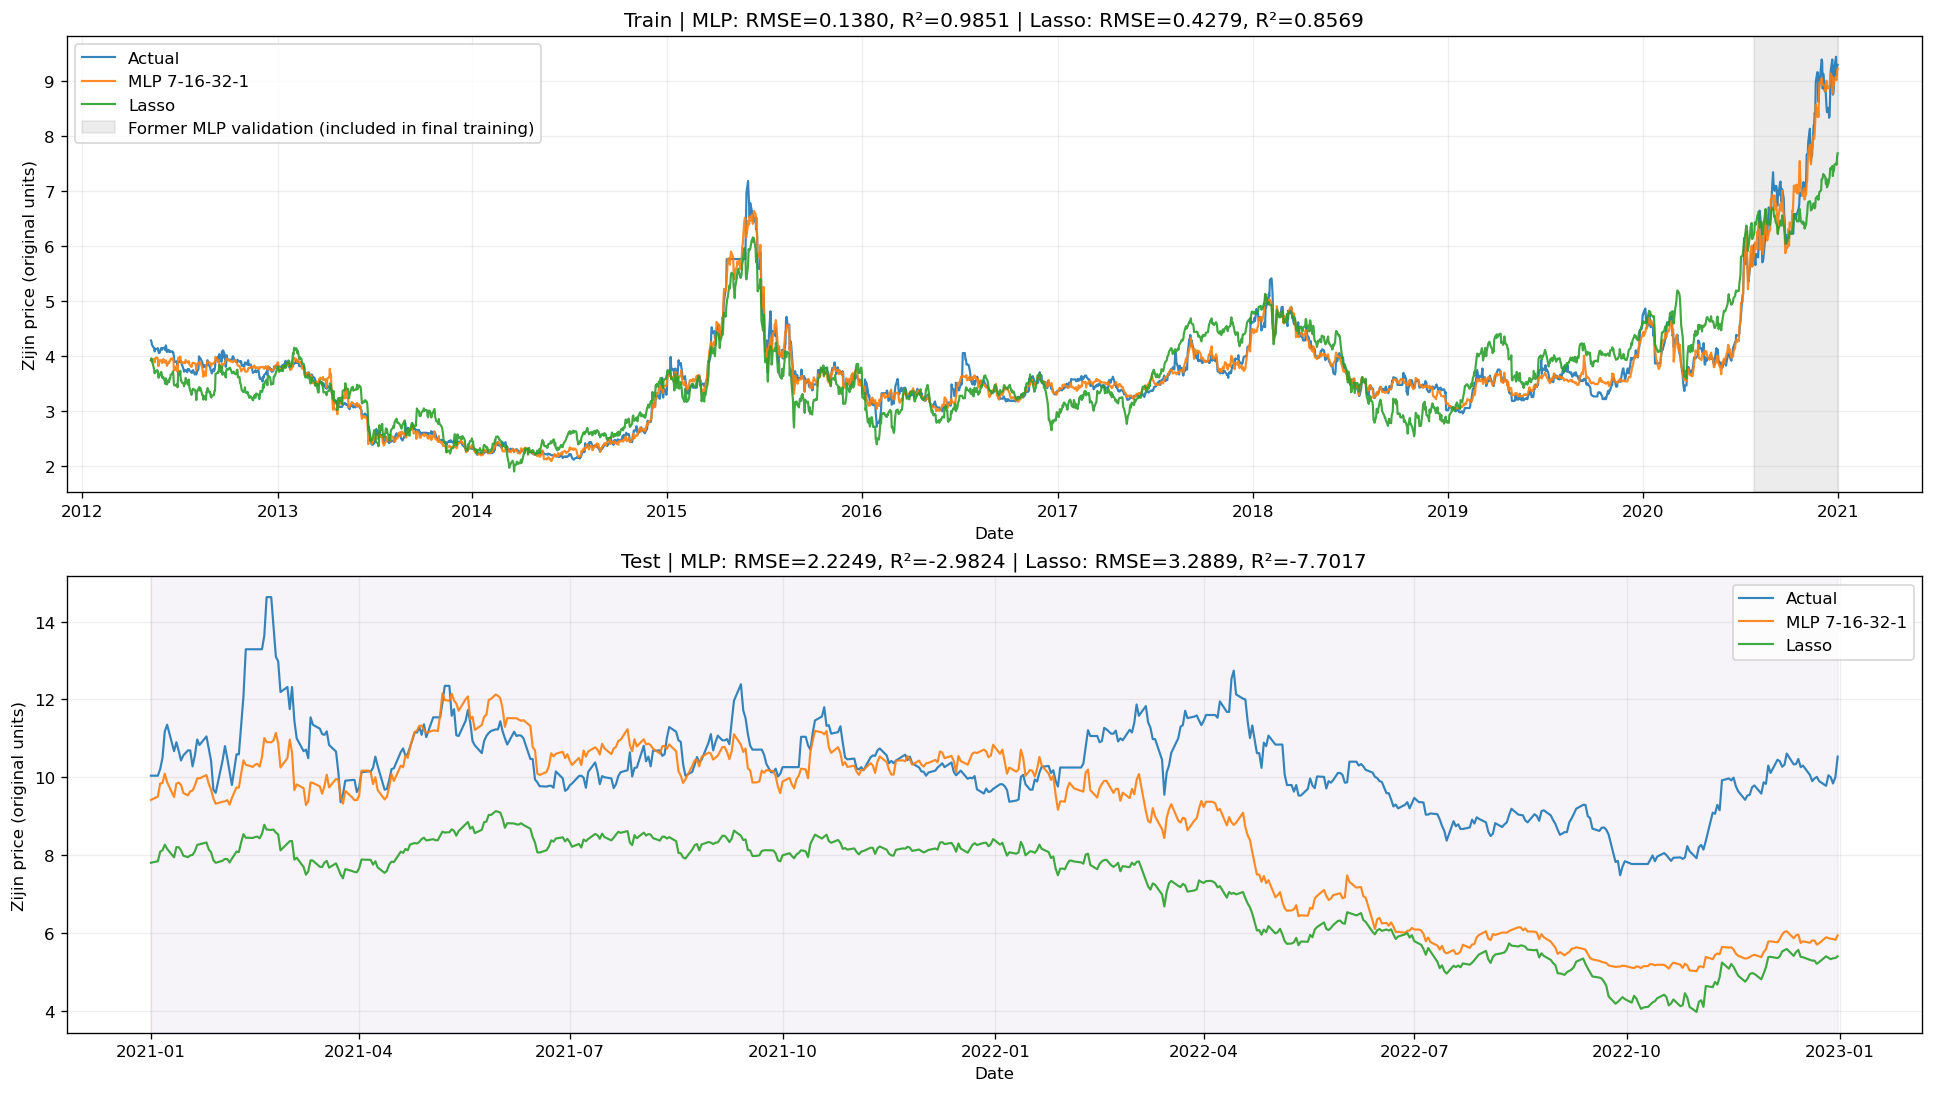

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)
for ax, split in zip(axes, ['Train', 'Test']):
    frame = comparison_predictions[split]
    for name, color in [('Actual', 'tab:blue'), ('MLP', 'tab:orange'), ('Lasso', 'tab:green')]:
        ax.plot(frame.index, frame[name], color=color, label='MLP 7-16-32-1' if name == 'MLP' else name, linewidth=1.3, alpha=0.9)
    if split == 'Train':
        ax.axvspan(X_val.index.min(), X_val.index.max(), color='gray', alpha=0.15,
                   label='Former MLP validation (included in final training)')
    else:
        ax.axvspan(frame.index.min(), frame.index.max(), color='tab:purple', alpha=0.08)
    row_mlp = comparison_metrics.loc[(split, 'MLP')]
    row_lasso = comparison_metrics.loc[(split, 'Lasso')]
    ax.set(title=f'{split} | MLP: RMSE={row_mlp.RMSE:.4f}, R²={row_mlp["R²"]:.4f}'
           f' | Lasso: RMSE={row_lasso.RMSE:.4f}, R²={row_lasso["R²"]:.4f}',
           xlabel='Date', ylabel='Zijin price (original units)')
    ax.grid(alpha=0.2)
    ax.legend()
fig.savefig(OUT / 'mlp_lasso_predictions.png', dpi=140)
plt.show()


## 历史区间实验结果与假设检查

| 数据段     |   记录数 | 开始                | 结束                |
|:-----------|---------:|:--------------------|:--------------------|
| 完整训练集 |     2325 | 2012-05-09 00:00:00 | 2020-12-31 00:00:00 |
| 内部拟合集 |     2208 | 2012-05-09 00:00:00 | 2020-07-24 00:00:00 |
| 内部验证集 |      117 | 2020-07-27 00:00:00 | 2020-12-31 00:00:00 |
| 测试集     |      546 | 2021-01-01 00:00:00 | 2022-12-31 00:00:00 |

MLP 最佳 **287 轮**，实际 **387 轮**停止；完整训练集重训 287 轮。Lasso 最佳 alpha **0.0087688561**。

|                    |     MSE |   RMSE |    MAE |      R² |
|:-------------------|--------:|-------:|-------:|--------:|
| ('Train', 'MLP')   |  0.0191 | 0.138  | 0.097  |  0.9851 |
| ('Train', 'Lasso') |  0.1831 | 0.4279 | 0.3231 |  0.8569 |
| ('Test', 'MLP')    |  4.9503 | 2.2249 | 1.7273 | -2.9824 |
| ('Test', 'Lasso')  | 10.8166 | 3.2889 | 3.127  | -7.7017 |

测试期仍超出完整训练期范围的因子：A_500：3.11%；Dollar Index：30.40%；us_10y_rate：17.95%；brent：6.23%；Copper Futures Price：69.23%。

本次测试 RMSE 较小的是 **MLP**。先检查范围覆盖是否符合假设，再解释预测指标；早期年份不自动意味着输入或关系稳定，不能把年份提前本身作为外推问题消失的证据。单次划分不能确定预测误差的因果来源。

保留原数据记录与同日解释股价口径，未重新审计历史填充；2023 年及以后记录未用于本次训练和评价。结果保存于 `results/mlp_two_layer_test_2021_2022/`。修改参数后需更新本段。

## 修正测试截止日：2021-01-01 至 2022-01-01（含截止日）


**训练与验证不变**：完整训练集截至 2020-12-31，共 2325 条；内部拟合集 2208 条，验证集为末尾 5%，117 条，2020-07-27 至 2020-12-31。

测试范围改为 **2021-01-01 ≤ 日期 ≤ 2022-01-01**，实际数据范围 2021-01-01～2021-12-31，共 **272 条**。

训练数据、验证数据与超参数均未改变，原来历史区间实验的权重和选参结果可以直接复用；这里只截取已保存的测试预测，重新计算指标。MLP 最佳 **287 轮**，第 **387 轮**停止。没有使用测试结果重新选轮或调参。

|                    |    MSE |   RMSE |    MAE |      R² |
|:-------------------|-------:|-------:|-------:|--------:|
| ('Train', 'MLP')   | 0.0191 | 0.138  | 0.097  |  0.9851 |
| ('Train', 'Lasso') | 0.1831 | 0.4279 | 0.3231 |  0.8569 |
| ('Test', 'MLP')    | 0.8444 | 0.9189 | 0.6534 | -0.1067 |
| ('Test', 'Lasso')  | 6.884  | 2.6237 | 2.5023 | -8.0225 |

下方保留相同训练过程的 MSE 曲线，以及修正时间范围后的预测对比图。指标只评价这一测试窗口；不代表输入范围或数据关系稳定性的证明。

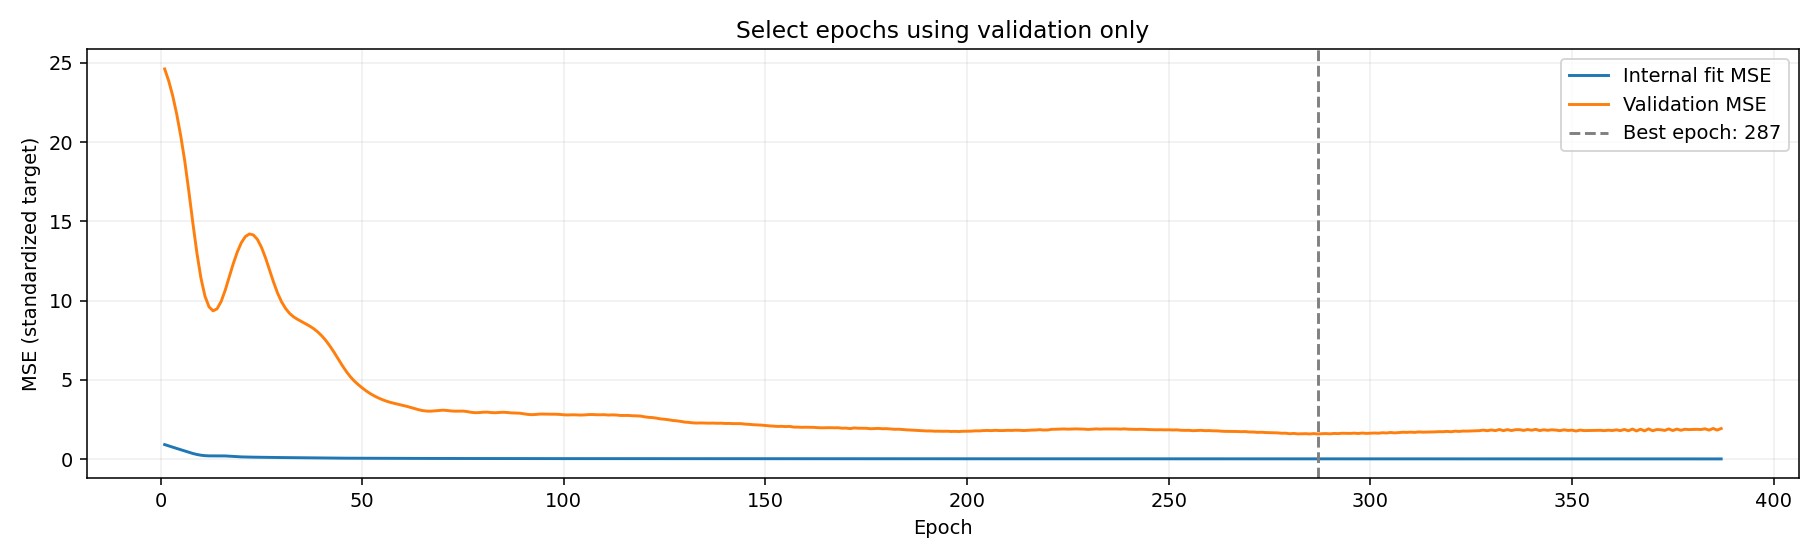

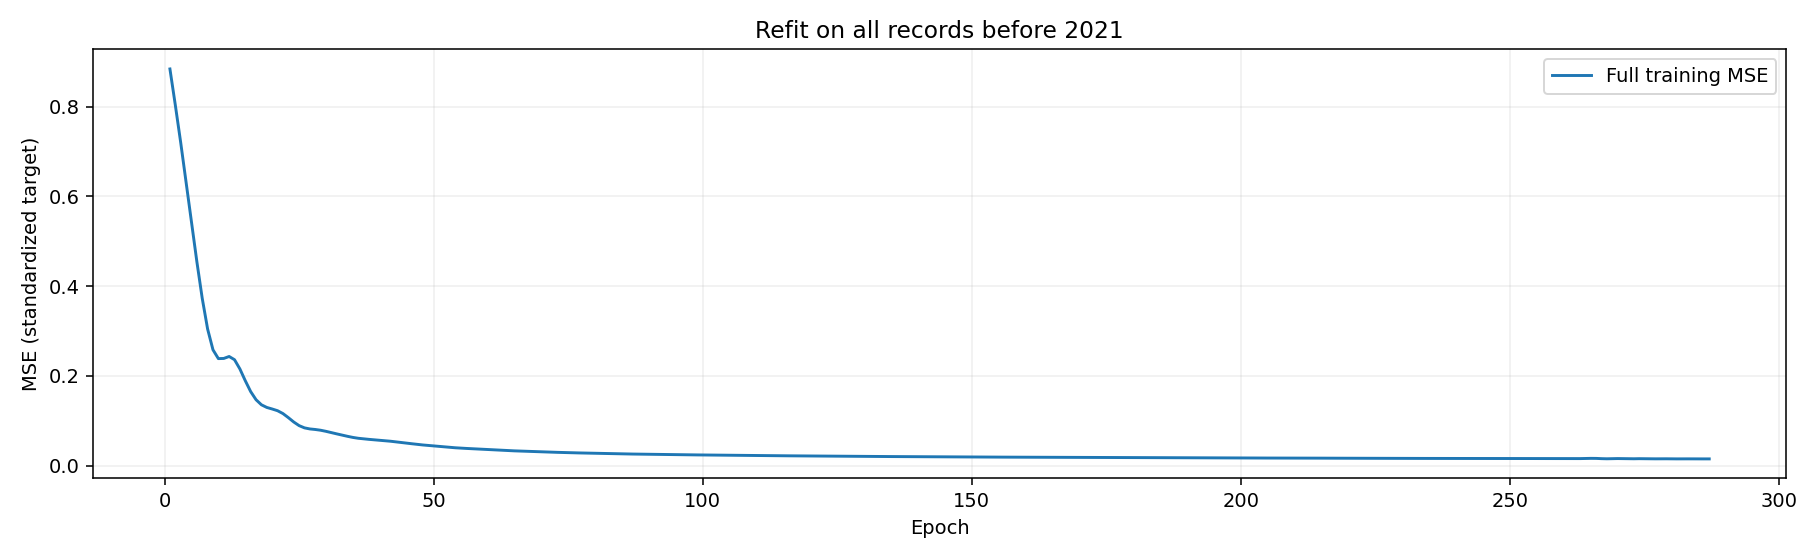

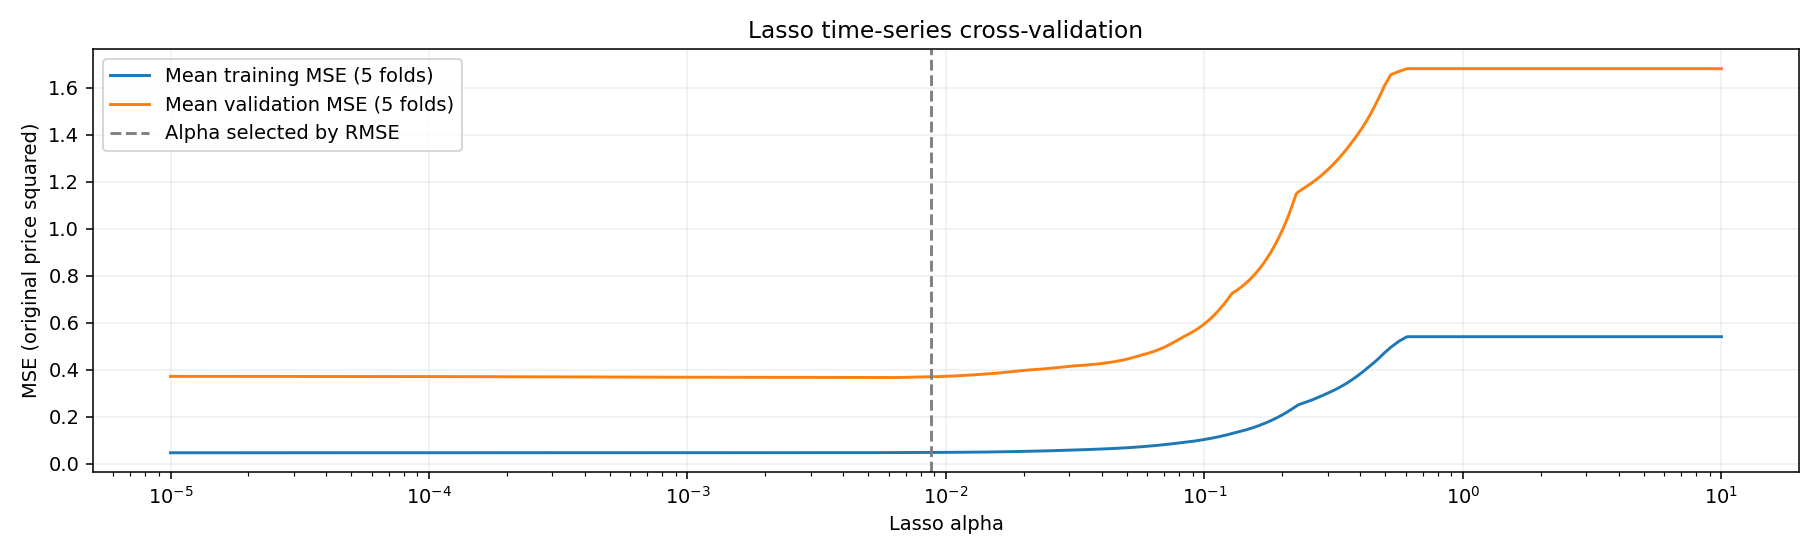

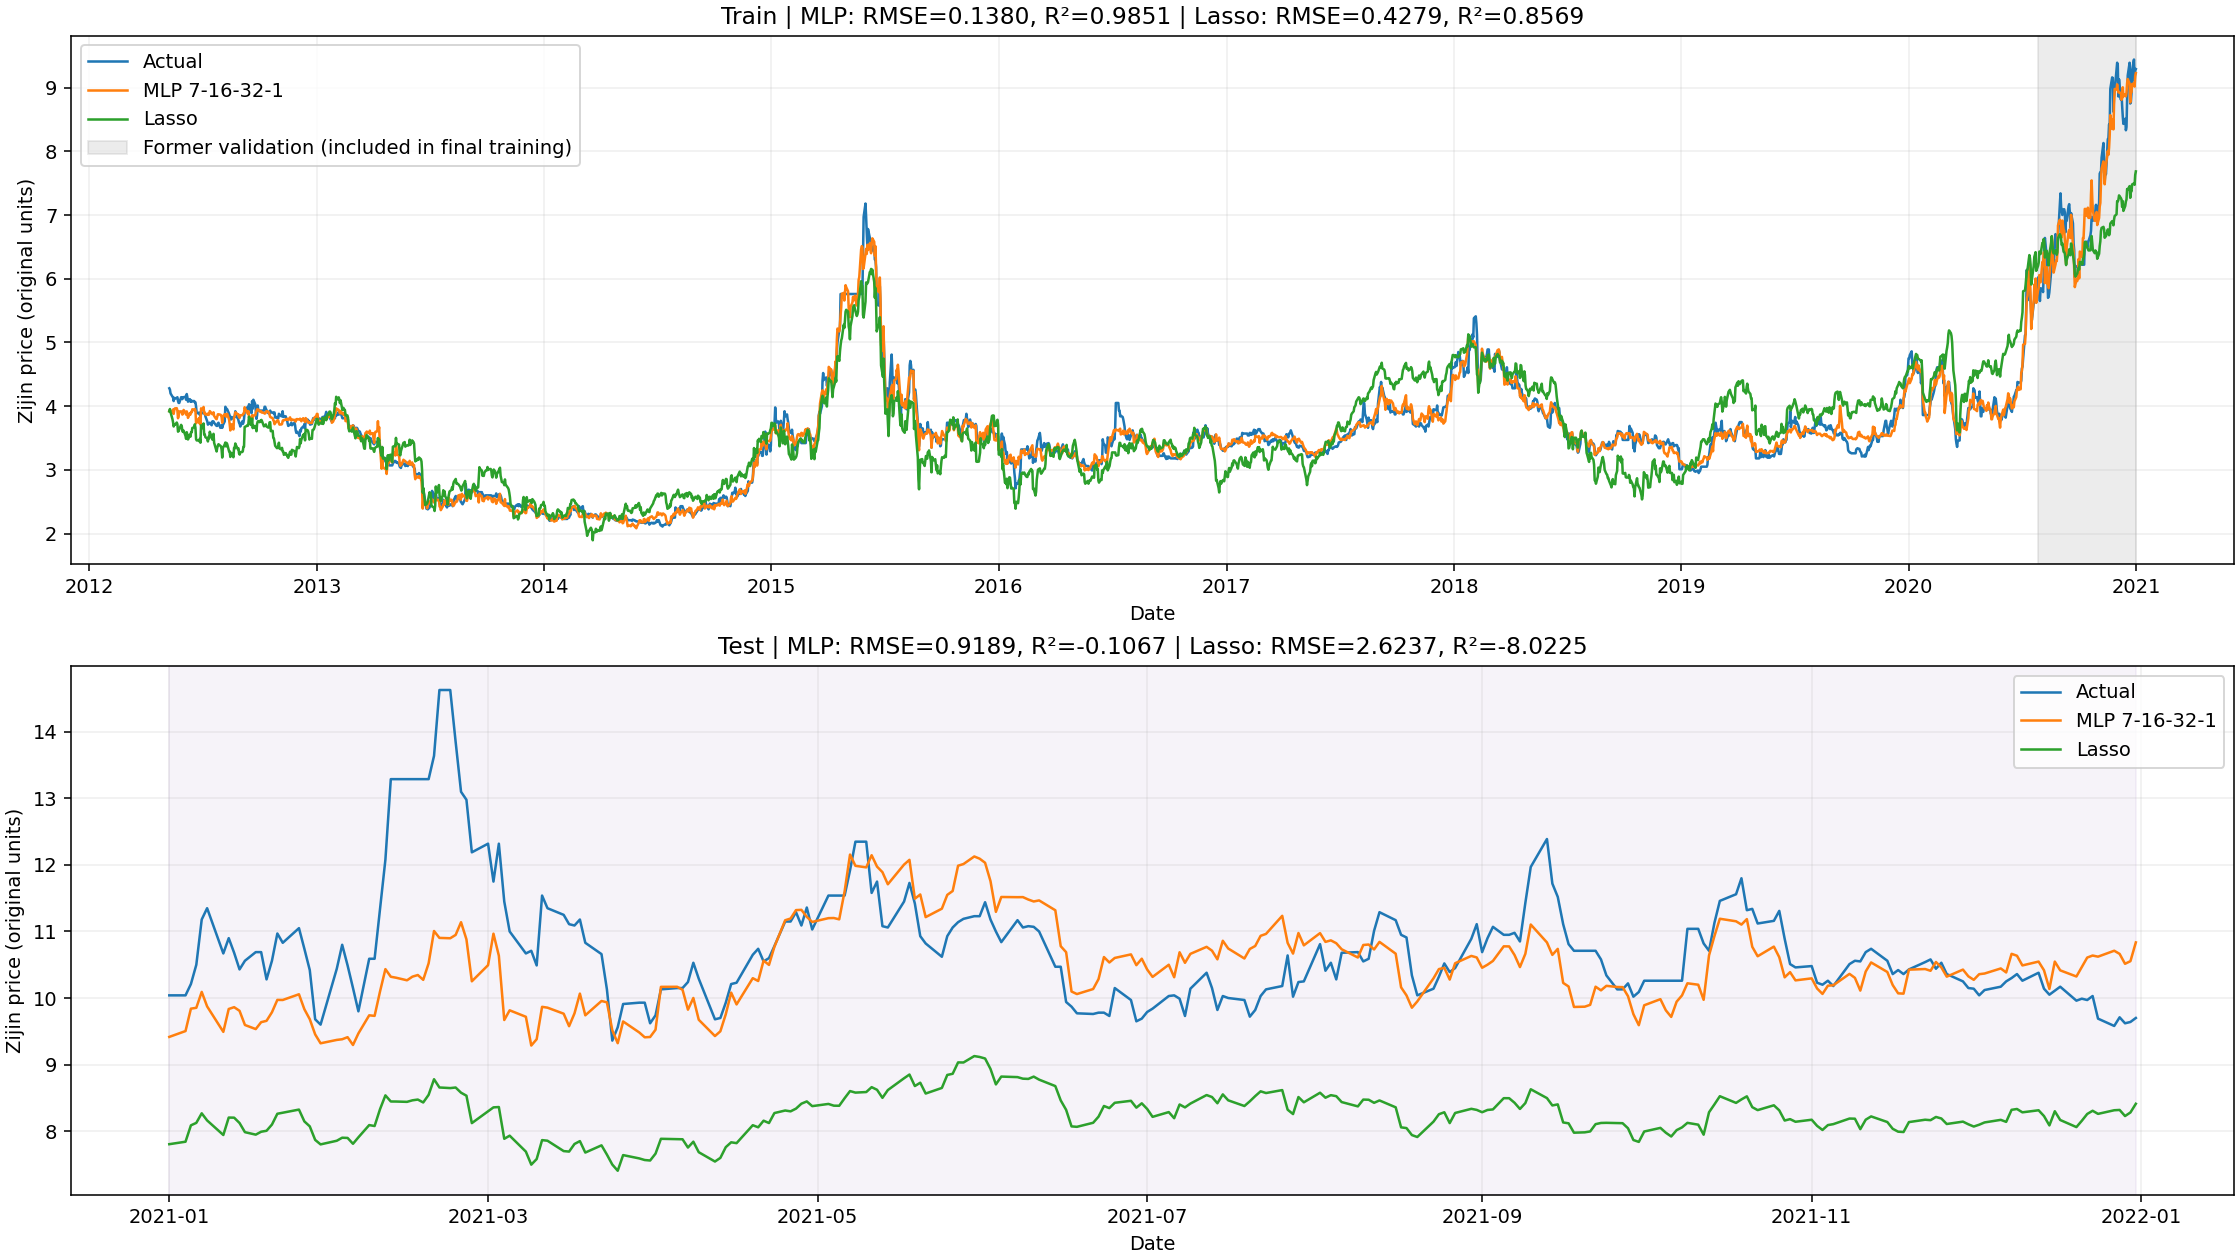

In [ ]:
from pathlib import Path
from IPython.display import Image, display
result_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/pickle/Dataset.pkl').exists())
for name in ['results/mlp_two_layer_test_2021_2022/selection_mse.png', 'results/mlp_two_layer_test_2021_2022/refit_mse.png', 'results/mlp_two_layer_test_2021_2022/lasso_cv_mse.png', 'results/mlp_two_layer_test_until_2022_01_01/mlp_lasso_predictions.png']:
    display(Image(filename=str(result_root / name)))

从训练集中,我们看到MLP已近乎完美21年的突变.而在价格相对平稳的21-22年,表现相比线性模型更好.在训练和测试集表现更是如此.  
22年以后,铜价,金价等大幅变动,在训练时候未见过此情况,因此预测表现大幅下降.过去的经验放到现在并不好用.

此前的实验我们是把过去的经验也纳入其中,拟合是以总体最优为基准进行计算的.  
通过对01_MLP的构建 的观察,如果我们把数据集压缩到26年之前,从20年开始,基本也包含了所有的数据范围.以更近一点的数据集进行训练,是否能更好的拟合当前的状况,较少考虑过去的经验.

## 缩短历史窗口：2020 年起训练，2026 年起测试

本次只保留 **2020-01-01 起至现有数据末尾**的数据，不联网更新数据。完整训练集为 **2020-01-01 ≤ 日期 < 2026-01-01**，末尾 5%（按记录数向上取整）留作内部验证，测试集为 **2026-01-01 及以后**。边界没有重复样本。

| 数据段     |   记录数 | 开始                | 结束                |
|:-----------|---------:|:--------------------|:--------------------|
| 完整训练集 |     1631 | 2020-01-01 00:00:00 | 2025-12-31 00:00:00 |
| 内部拟合集 |     1549 | 2020-01-01 00:00:00 | 2025-09-10 00:00:00 |
| 内部验证集 |       82 | 2025-09-11 00:00:00 | 2025-12-31 00:00:00 |
| 测试集     |      152 | 2026-01-01 00:00:00 | 2026-07-23 00:00:00 |

其余设置沿用：两层 MLP **7→16→32→1**、seed=42、Adam、学习率 0.01、2000 轮上限，验证标准化 MSE 改善超过 1e-6 才更新最佳记录，连续 100 轮无改善则早停。本次最佳 **454 轮**，第 **554 轮**停止；随后在完整训练集重新初始化训练 454 轮。

Lasso 仍采用标准化 Pipeline、五折时间序列交叉验证、10⁻⁵～10¹ 的 1000 个 alpha；最佳 alpha **0.12826498**。两者最终看到相同的完整训练集，测试数据不参与选参。

|                    |     MSE |   RMSE |    MAE |      R² |
|:-------------------|--------:|-------:|-------:|--------:|
| ('Train', 'MLP')   |  0.1721 | 0.4149 | 0.3115 |  0.9948 |
| ('Train', 'Lasso') |  2.3627 | 1.5371 | 1.1333 |  0.9286 |
| ('Test', 'MLP')    | 39.5908 | 6.2921 | 5.2082 | -1.3113 |
| ('Test', 'Lasso')  | 11.1844 | 3.3443 | 2.8063 |  0.347  |

输入范围覆盖检查：

|                      |   验证超出内部拟合范围 (%) |   测试超出内部拟合范围 (%) |   测试超出完整训练范围 (%) |
|:---------------------|---------------------------:|---------------------------:|---------------------------:|
| A_500                |                       0    |                       0    |                       0    |
| Dollar Index         |                       0    |                       0    |                       0    |
| cn_10y_rate          |                       0    |                       0    |                       0    |
| us_10y_rate          |                       0    |                       0    |                       0    |
| brent                |                       0    |                       1.97 |                       1.97 |
| Copper Futures Price |                       1.22 |                      76.97 |                      73.03 |
| Gold Futures Price   |                      98.78 |                     100    |                      61.84 |

下方依次展示 MLP 内部拟合／验证 MSE、完整训练 MSE、Lasso 交叉验证 MSE 和预测对比。灰色段曾用于验证，已参与最终重训；淡紫色为测试期。不新增残差图。

缩短历史窗口可能减少旧关系的影响，也减少了训练样本与情形覆盖；本次结果不能单独证明旧数据就是误差原因。前面“2026 年起测试”的实验使用的是 7→8→1 网络，本次是 7→16→32→1，不能直接将两者差异全部归因于窗口缩短。原始数据及同日解释口径的限制仍然存在。

结果、配套模型参数、预测明细及可复现脚本保存在 `results/mlp_two_layer_from2020_test2026/`。

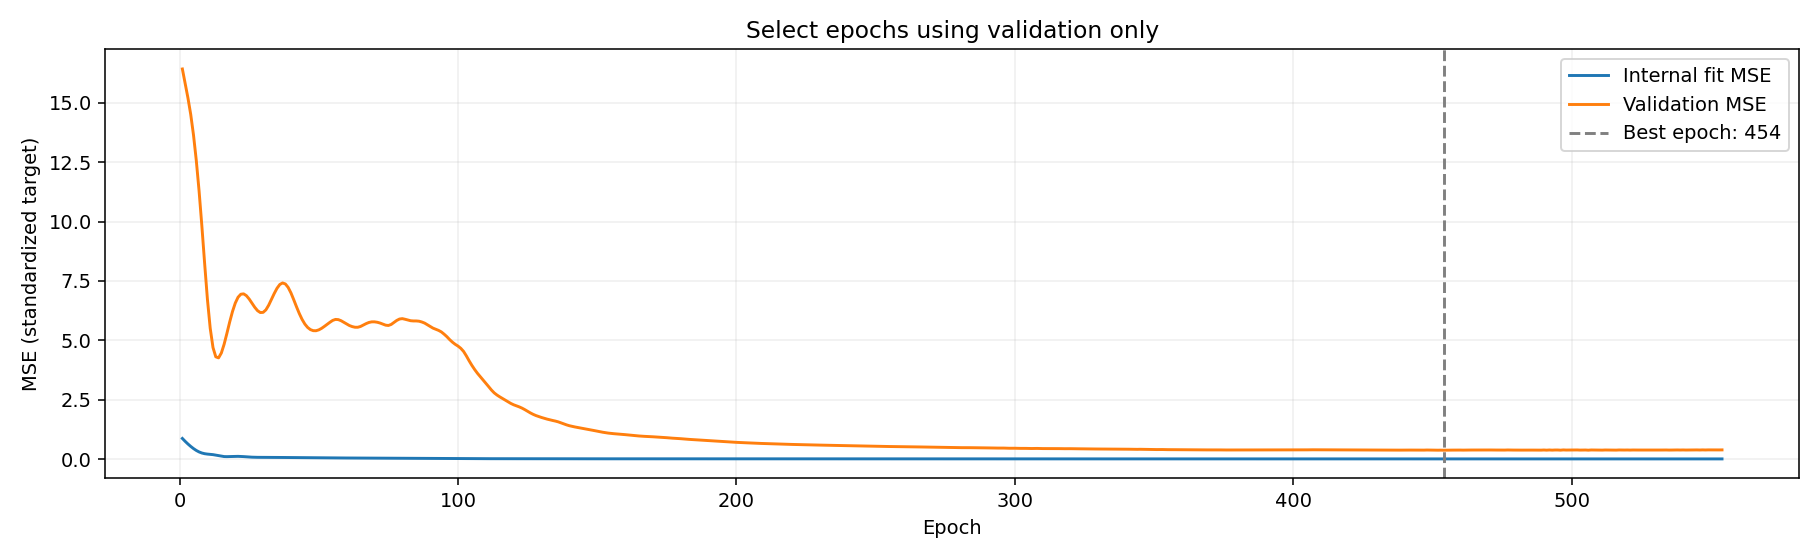

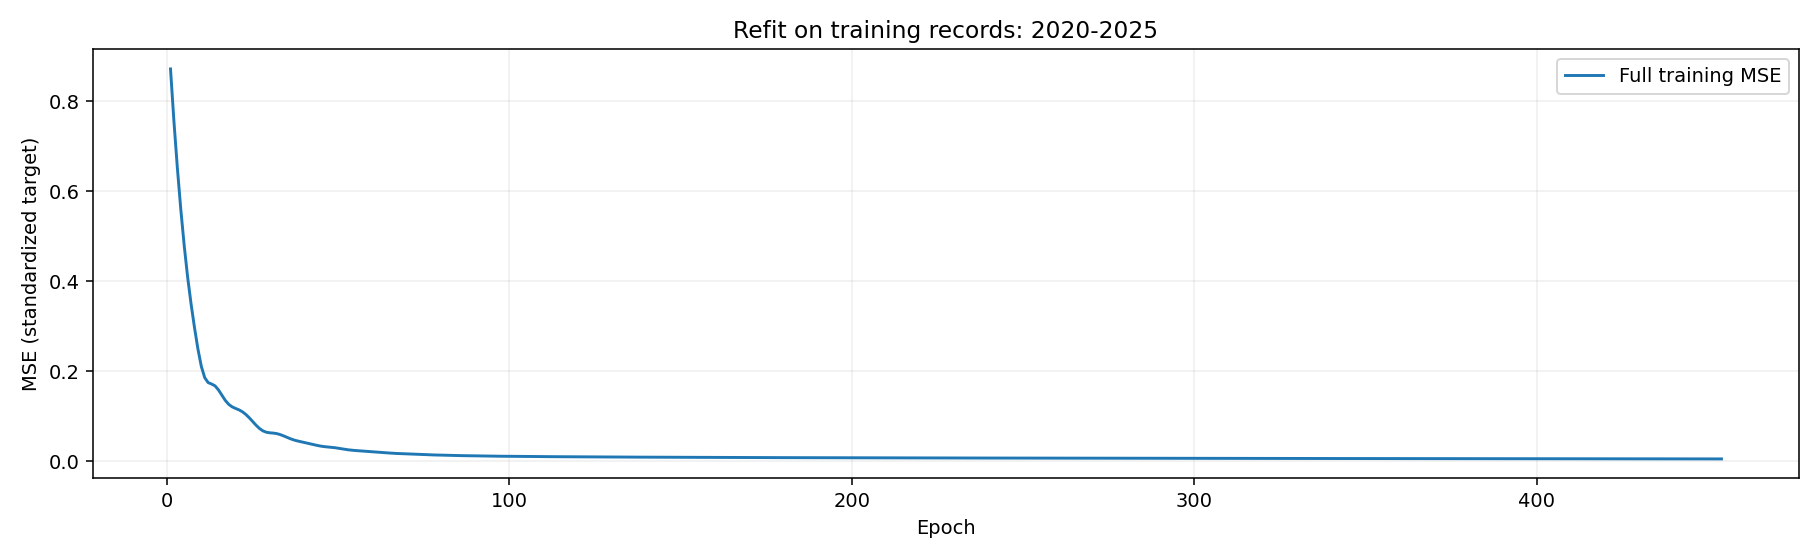

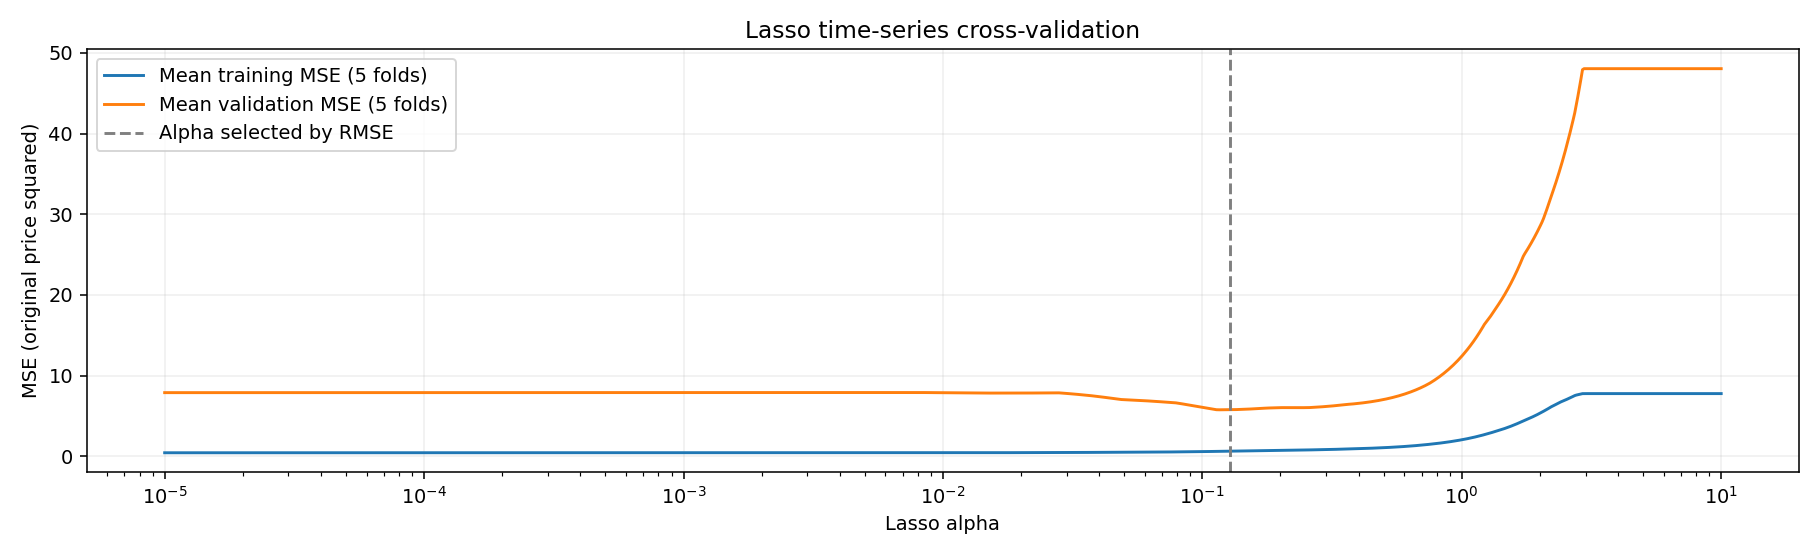

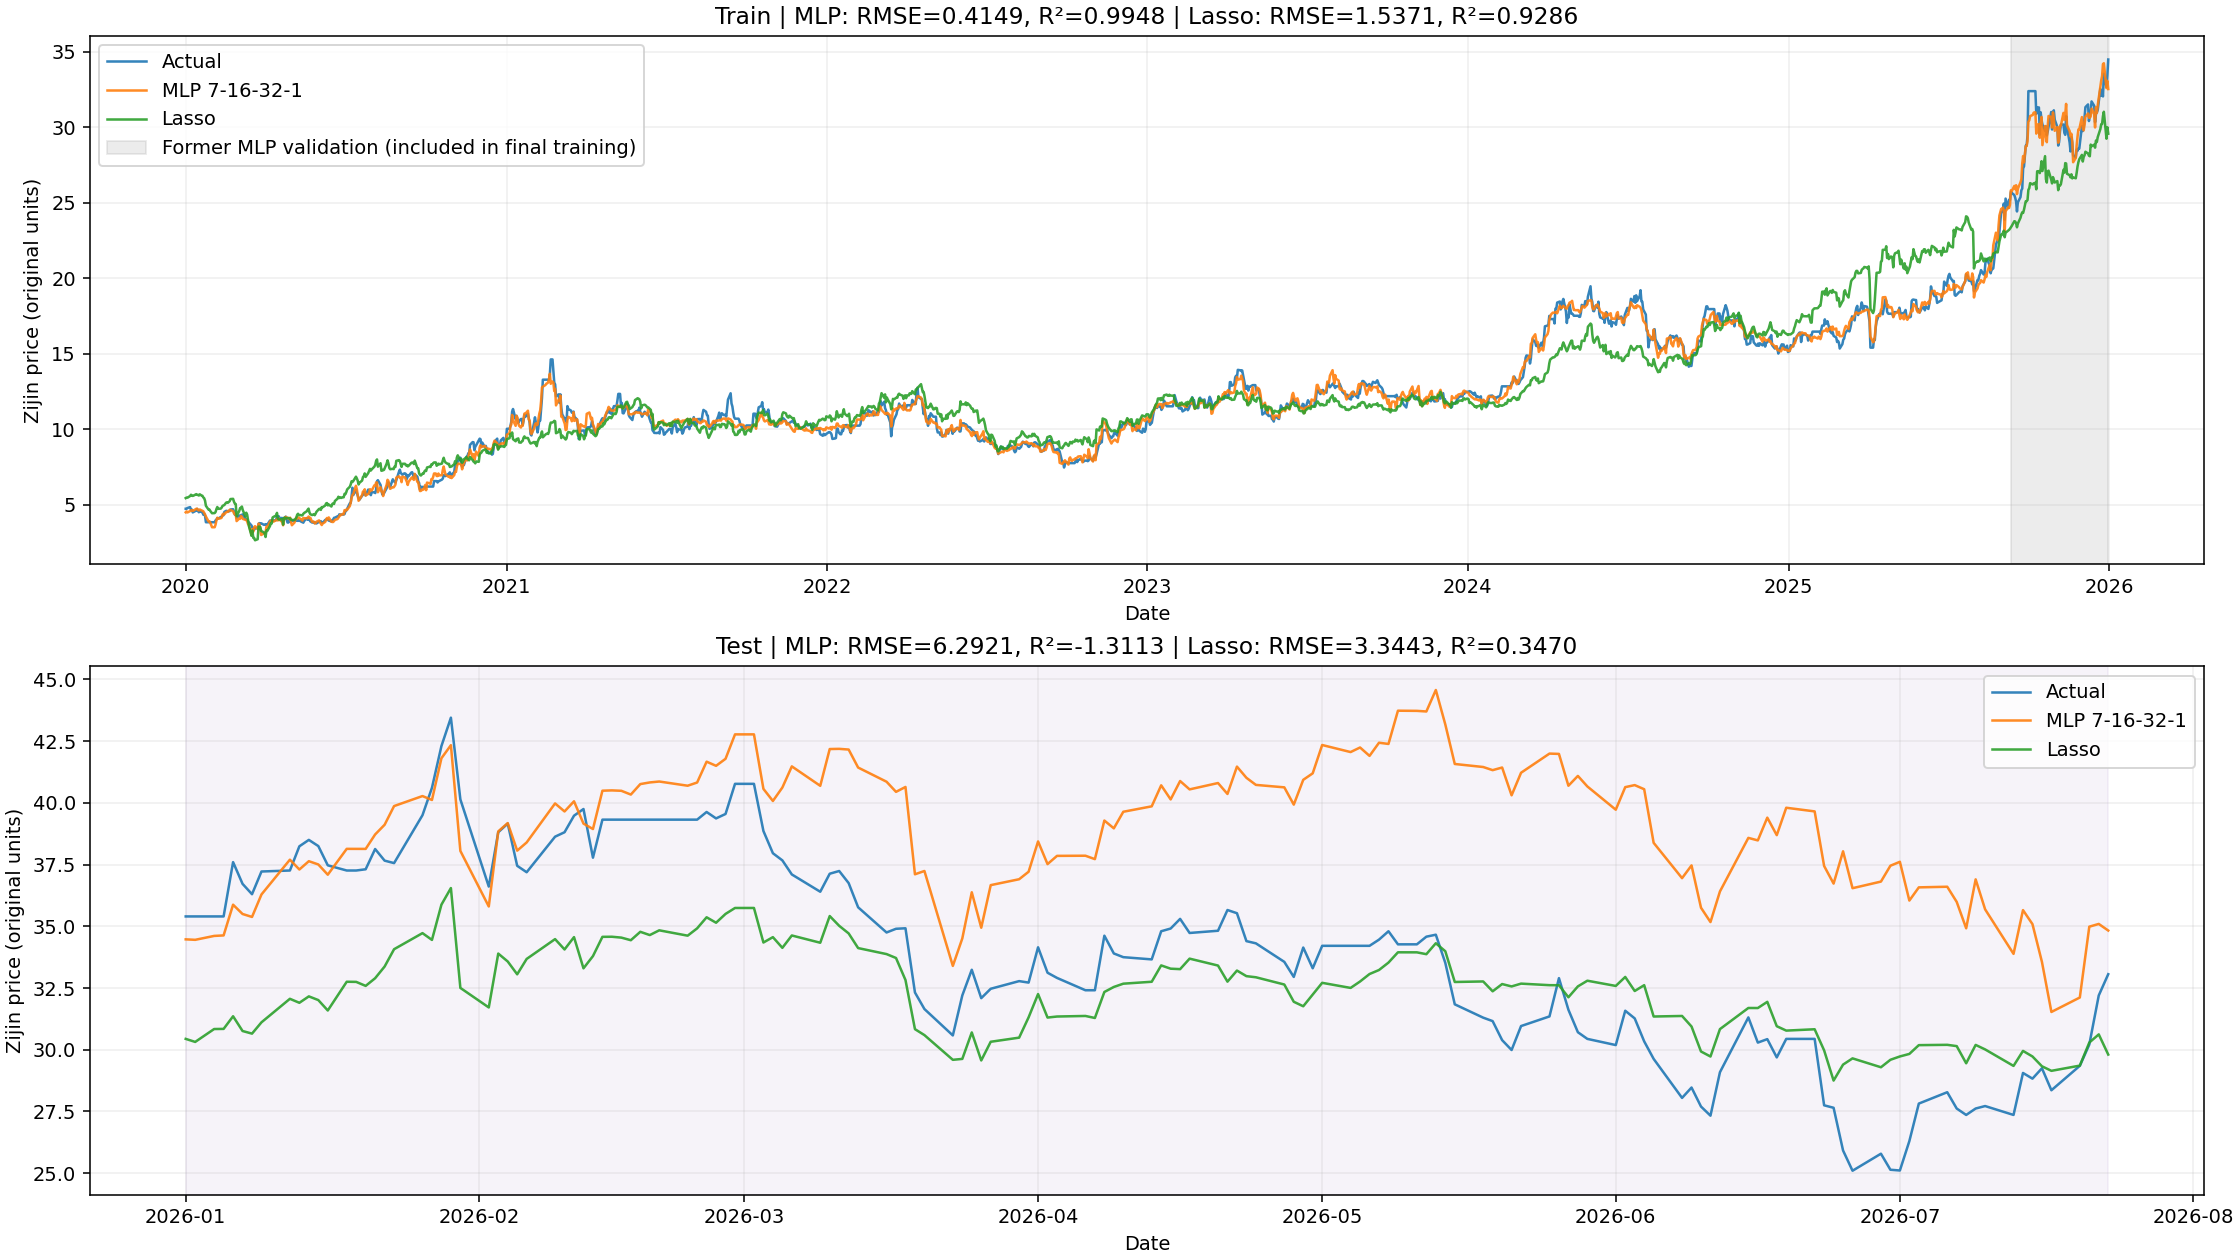

In [ ]:
from pathlib import Path
from IPython.display import Image, display
result_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/pickle/Dataset.pkl').exists())
for name in ['selection_mse.png', 'refit_mse.png', 'lasso_cv_mse.png', 'mlp_lasso_predictions.png']:
    display(Image(filename=str(result_root / 'results/mlp_two_layer_from2020_test2026' / name)))

## 仅比较 MLP：完整历史与 2020 年起的训练窗口

两组均使用 **7→16→32→1、seed=42、Adam、LR=0.01、最多 2000 轮、连续 100 轮验证 MSE 未改善早停（MIN_DELTA=1e-6）**。完整历史指现有数据全部历史起点 2012-05-09；近期窗口从 2020 年开始。两组训练均截至 2025-12-31，分别留出末尾 **5%** 内部验证，选轮后在各自完整训练集重训。

测试集完全相同：**2026-01-01 至 2026-07-23，152 条**。下面只展示 MLP 结果和一张测试期预测对比图，不显示 Lasso 和中间训练曲线。

| 训练窗口   | 训练起始   | 训练结束   |   完整训练数 |   验证数 | 验证起始   | 验证结束   |   最佳轮数 |   停止轮数 |
|:-----------|:-----------|:-----------|-------------:|---------:|:-----------|:-----------|-----------:|-----------:|
| full       | 2012-05-09 | 2025-12-31 |         3685 |      185 | 2025-04-24 | 2025-12-31 |         12 |        112 |
| recent     | 2020-01-01 | 2025-12-31 |         1631 |       82 | 2025-09-11 | 2025-12-31 |        454 |        554 |

|                                 |   样本数 |     MSE |   RMSE |    MAE |      R² |
|:--------------------------------|---------:|--------:|-------:|-------:|--------:|
| ('完整历史（2012起）', 'Train') |     3685 |  7.3729 | 2.7153 | 2.0677 |  0.7936 |
| ('完整历史（2012起）', 'Test')  |      152 | 30.0512 | 5.4819 | 4.9294 | -0.7544 |
| ('近期历史（2020起）', 'Train') |     1631 |  0.1721 | 0.4149 | 0.3115 |  0.9948 |
| ('近期历史（2020起）', 'Test')  |      152 | 39.5908 | 6.2921 | 5.2082 | -1.3113 |

对比结论以共同测试段为准，训练误差的样本范围不同。由于按比例保留验证集，两组验证日期和选定轮数也不同，所以本实验比较的是两种训练窗口方案，不是严格隔离“旧数据影响”的因果实验。此前已查看过测试数据，此结果属于探索性比较。

参数、预测和可复现脚本保存在 `results/mlp_training_window_comparison/`。

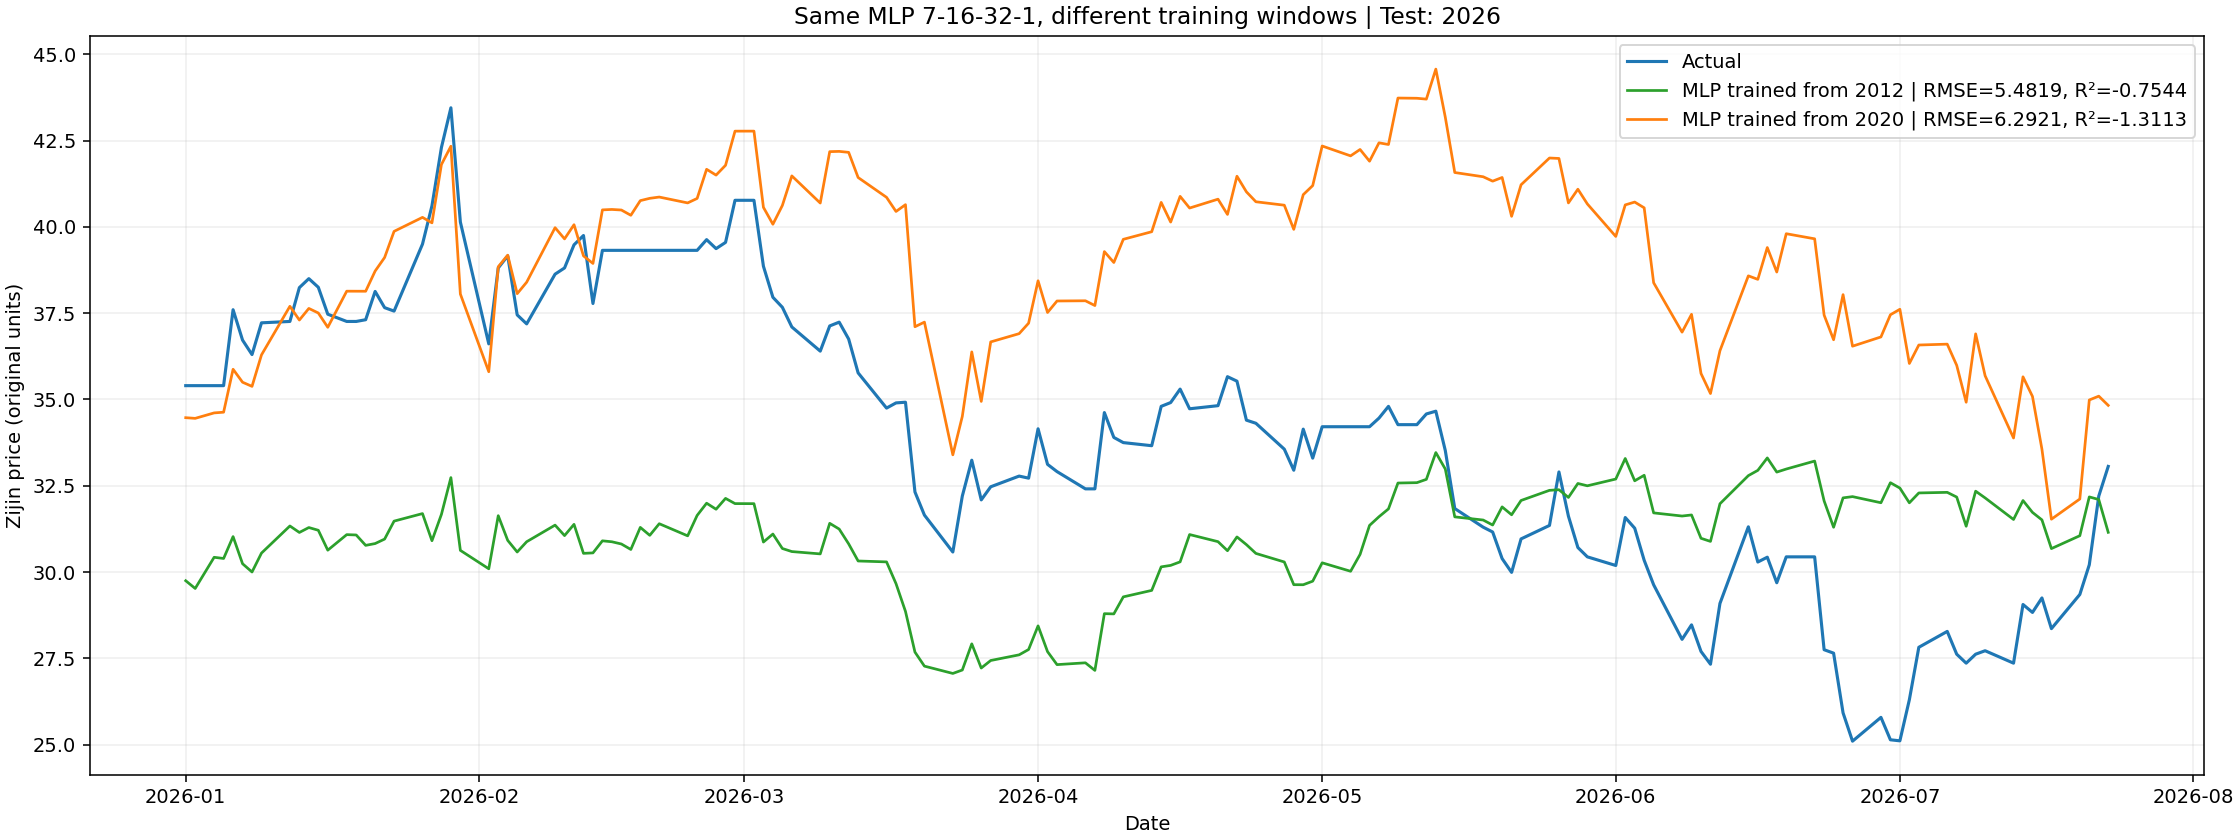

In [ ]:
from pathlib import Path
from IPython.display import Image, display
result_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/pickle/Dataset.pkl').exists())
display(Image(filename=str(result_root / 'results/mlp_training_window_comparison/mlp_window_comparison.png')))

单纯从RMSE和R^2来说,用完整历史训练的预测效果最好.  
虽然近期训练的拟合最好,但是他用于股价预测上,相对表现更差一点.  
但是我们不能说因为这一段时间预测的更好,就说某一个方法更好.由于我们想尽可能的捕捉到近期的变化,把训练集和验证集压缩的很小,可能未必能反应真实情况.

## 同一验证时间段比较：2025-09-11～2025-12-31

将两个模型的预测统一截取到上述日期，实际值与两条预测线放在同一张图中；RMSE、R²使用完全相同的82条样本重新计算。

使用各自**内部验证最佳权重**：2012 年起模型第12轮，2020 年起模型第454轮。该共同区间均未参与内部拟合权重的梯度更新，但参与各自选轮。原始拟合及验证窗口仍不同，因此这是相同评价区间的比较，不是重新统一两套训练流程。


,记录数,RMSE,R²
训练窗口,,,
2012 年起,82,6.7370,-8.5361
2020 年起,82,2.5944,-0.4142


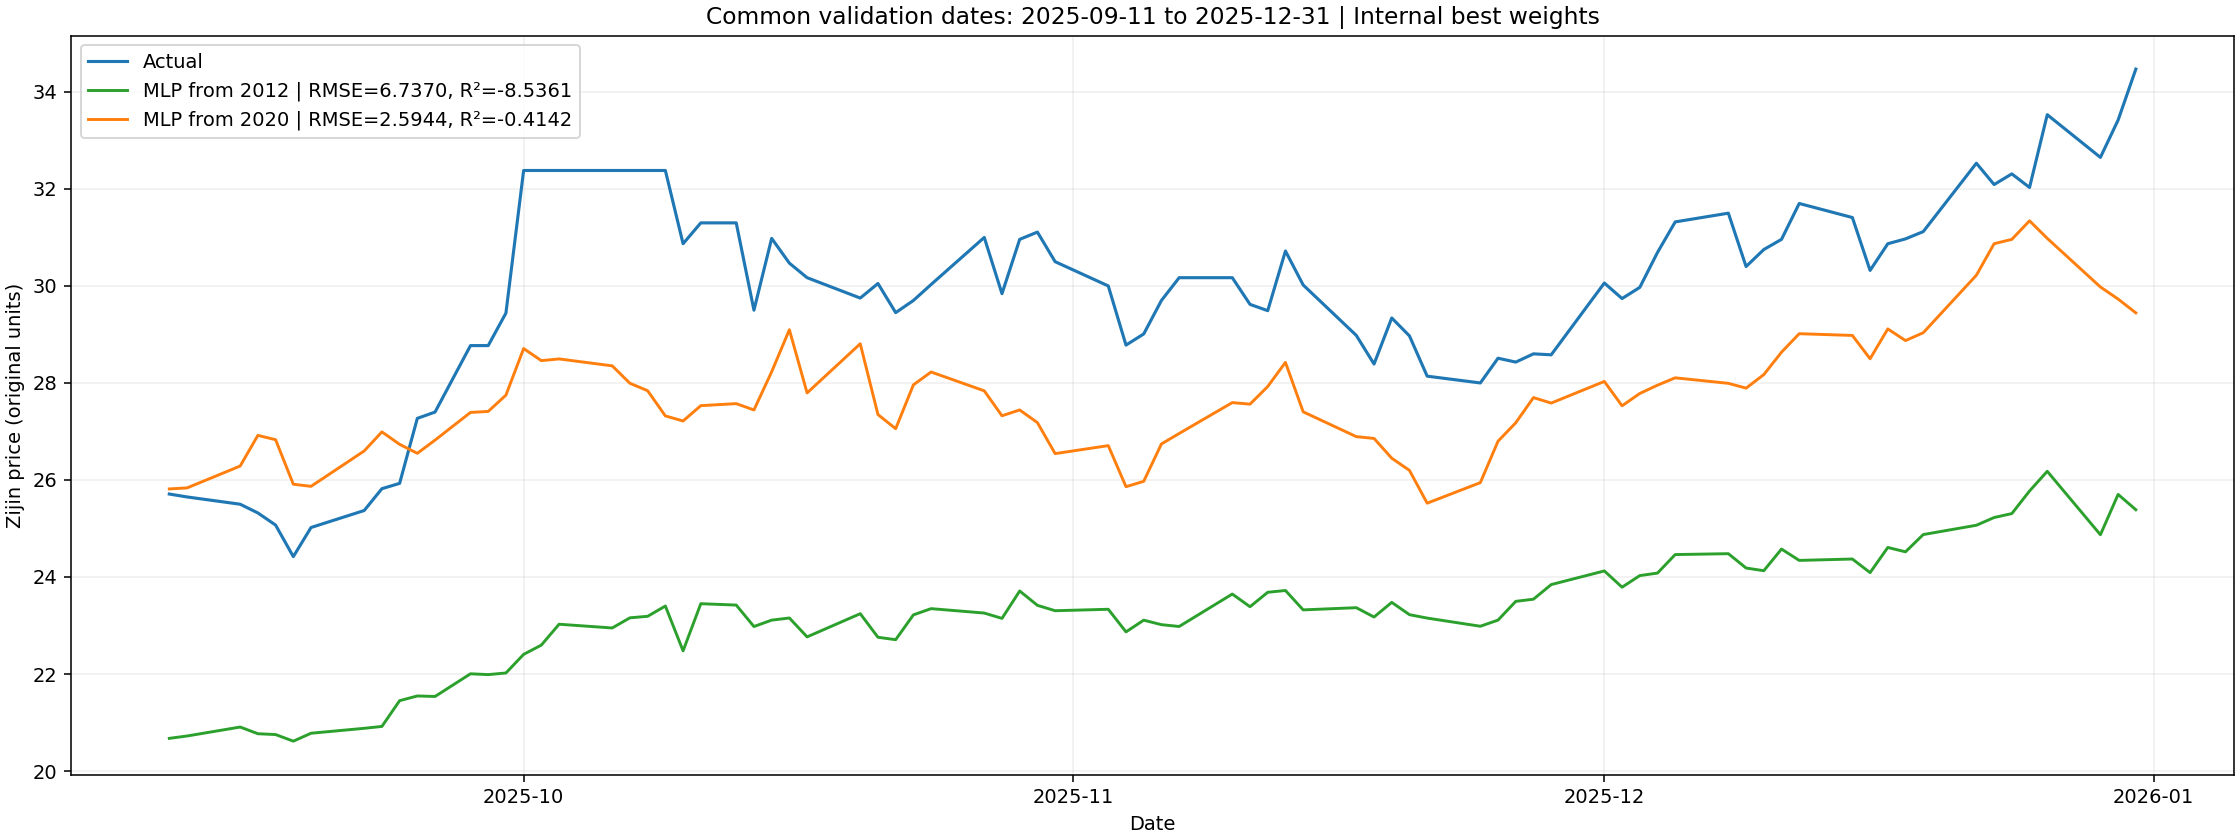

In [ ]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import display

val_zoom_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/pickle/Dataset.pkl').exists())
val_zoom_out = val_zoom_root / 'results/mlp_training_window_comparison'
val_zoom_path = val_zoom_root / 'src/pickle/Dataset.pkl'
val_zoom_dataset = pd.read_pickle(val_zoom_path)
val_zoom_rows, val_zoom_predictions = [], {}
val_zoom_axes = [None, None]
for ax, key, label, color in zip(val_zoom_axes, ['full', 'recent'],
    ['History from 2012', 'History from 2020'], ['tab:green', 'tab:orange']):
    ckpt = torch.load(val_zoom_out / key / 'mlp_checkpoint.pt', weights_only=True)
    assert ckpt['dataset_sha256'] == hashlib.sha256(val_zoom_path.read_bytes()).hexdigest()
    features = val_zoom_dataset['X']
    mask = ((features.index >= pd.Timestamp(ckpt['validation_start'])) &
            (features.index < pd.Timestamp(ckpt['validation_end_exclusive'])))
    features = features.loc[mask]
    truth = np.asarray(val_zoom_dataset['Y'].loc[features.index]).ravel()
    h1, h2 = ckpt['hidden_layers']
    candidate = nn.Sequential(nn.Linear(7, h1), nn.ReLU(), nn.Linear(h1, h2), nn.ReLU(), nn.Linear(h2, 1))
    # 使用内部最佳快照和配套的内部标准化器，不使用完整训练集重训权重。
    candidate.load_state_dict(ckpt['internal_best_state_dict'])
    candidate.eval()
    sx, sy = ckpt['scaler_x_internal'], ckpt['scaler_y_internal']
    tensor = torch.tensor((features.to_numpy() - np.array(sx['mean'])) / np.array(sx['scale']), dtype=torch.float32)
    with torch.no_grad():
        pred = candidate(tensor).numpy().ravel() * sy['scale'][0] + sy['mean'][0]
    mse = mean_squared_error(truth, pred)
    rmse, r2 = np.sqrt(mse), r2_score(truth, pred)
    history = pd.read_csv(val_zoom_out / key / 'selection_history.csv').set_index('epoch')
    assert np.isclose(mse / sy['scale'][0] ** 2, history.loc[ckpt['best_epoch'], 'val_mse'], rtol=1e-5)
    frame = pd.DataFrame({'Actual': truth, 'Predicted': pred}, index=features.index)
    val_zoom_predictions[key] = frame
    frame.to_csv(val_zoom_out / f'{key}_validation_predictions.csv')
    val_zoom_rows.append({'训练窗口': label, '验证起始': features.index.min().date(),
        '验证结束': features.index.max().date(), '记录数': len(features), '最佳轮数': ckpt['best_epoch'],
        'RMSE': rmse, 'R²': r2})

common_predictions = {key: frame.loc['2025-09-11':'2025-12-31'].copy()
                      for key, frame in val_zoom_predictions.items()}
assert common_predictions['full'].index.equals(common_predictions['recent'].index)
assert np.allclose(common_predictions['full'].Actual, common_predictions['recent'].Actual)
common_rows = []
for key, label in [('full', '2012 年起'), ('recent', '2020 年起')]:
    frame = common_predictions[key]
    common_rows.append({'训练窗口': label, '记录数': len(frame),
        'RMSE': np.sqrt(mean_squared_error(frame.Actual, frame.Predicted)),
        'R²': r2_score(frame.Actual, frame.Predicted)})
common_metrics = pd.DataFrame(common_rows).set_index('训练窗口')
display(common_metrics.round(4))
common_metrics.to_csv(val_zoom_out / 'common_validation_metrics.csv')
common_frame = pd.DataFrame({'Actual': common_predictions['full'].Actual,
    'MLP_from_2012': common_predictions['full'].Predicted,
    'MLP_from_2020': common_predictions['recent'].Predicted})
common_frame.to_csv(val_zoom_out / 'common_validation_predictions.csv')
common_fig, common_ax = plt.subplots(figsize=(16, 6), constrained_layout=True)
common_ax.plot(common_frame.index, common_frame.Actual, color='tab:blue', label='Actual', linewidth=1.6)
for column, label, row, color in [
    ('MLP_from_2012', 'MLP from 2012', '2012 年起', 'tab:green'),
    ('MLP_from_2020', 'MLP from 2020', '2020 年起', 'tab:orange')]:
    common_ax.plot(common_frame.index, common_frame[column], color=color, linewidth=1.5,
        label=f'{label} | RMSE={common_metrics.loc[row, "RMSE"]:.4f}, R²={common_metrics.loc[row, "R²"]:.4f}')
common_ax.set(title='Common validation dates: 2025-09-11 to 2025-12-31 | Internal best weights',
              xlabel='Date', ylabel='Zijin price (original units)')
common_ax.xaxis.set_major_locator(mdates.MonthLocator())
common_ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
common_ax.grid(alpha=0.2)
common_ax.legend()
common_fig.savefig(val_zoom_out / 'common_validation_comparison.png', dpi=140)
plt.show()


在不同的数据集内,不同的模型表现不一.两个训练集不一样,一个偏高,一个偏低,学到的经验用于测试,具有一定的偶然性.